# การเตรียมข้อมูล การสำรวจข้อมูล ฝึกโมเดล และประเมิน UV ใน notebook เดียว

โมเดลนี้ฝึก SARIMAX **ในเครื่อง** แยกกรุงเทพ สงขลา และเชียงใหม่ เป้าหมายคือ TEMIS UV ภายใต้ท้องฟ้าโปร่ง ณ เที่ยงสุริยะ ไม่ใช่ UV ที่ผู้ใช้ได้รับจริง และไม่ได้เรียก API โมเดลพยากรณ์สำเร็จรูป

**โครงสร้างของ notebook**

| ส่วน | เนื้อหา |
|---|---|
| 1 | เตรียมข้อมูล TEMIS (ดาวน์โหลด ตรวจสอบ เขียน CSV) |
| 2 | **Exploratory Data Analysis** — กราฟอนุกรมเวลา, Trend / Seasonality / Cyclic, Missing Value และ Outlier |
| 3 | **Data Preprocessing** — ทดสอบ Stationarity (ADF, KPSS), พิจารณา Differencing, แบ่ง Train/Validation/Test |
| 4 | ฝึก SARIMAX ในเครื่อง |
| 5 | **สร้าง Forecasting Models 7 วิธี** และเปรียบเทียบบนภารกิจเดียวกัน |
| 6–8 | ประเมินผล (MAE, RMSE, MAPE), กราฟวินิจฉัย, ความเสี่ยงใกล้จุดแบ่งระดับ UV |
| 9 | **วิเคราะห์และสรุปผล** — โมเดลที่ดีที่สุด, การนำไปใช้เชิงนโยบาย, ข้อจำกัด |

**การรันรอบนี้:** 
- เซลล์เตรียมข้อมูลและฝึก SARIMAX (ส่วน 1 และ 4) *นิยามฟังก์ชันเท่านั้น* ไม่มีการเรียกดาวน์โหลดหรือ `fit()` เมื่อกด Run All
- ส่วน 2 และ 3 (EDA และ preprocessing) คำนวณจาก CSV ในเครื่องโดยตรง
- ส่วน 5 ฝึกโมเดลเปรียบเทียบที่มีต้นทุนต่ำ (moving average, exponential smoothing, random forest) ภายใน notebook และดึงผล SARIMAX จาก backtest ที่บันทึกไว้ ไม่มีการเขียนทับ artifact ของระบบจริง
- ส่วน 6 เป็นต้นไปอ่าน CSV, metrics และผล backtest ที่เคยบันทึกไว้ ตรวจความสอดคล้อง แล้วสร้างตารางและกราฟใหม่ หากไฟล์เหล่านั้นหาย notebook จะหยุดพร้อมข้อความชัดเจนแทนการฝึกใหม่อัตโนมัติ

In [1]:
from pathlib import Path
from datetime import date
import csv
import json

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
for candidate in (ROOT, *ROOT.parents):
    if (candidate / "pyproject.toml").exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError("Run this notebook inside the Aphrodize repository")

plt.style.use("ggplot")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
CITY_LABELS = {"bangkok": "Bangkok", "songkhla": "Songkhla", "chiang_mai": "Chiang Mai"}
print("Repository:", ROOT)

CITIES = ("bangkok", "songkhla", "chiang_mai")


Repository: D:\CoE Y.4 T.1\241-353\code\Aphrodize


## 1. เตรียมข้อมูล TEMIS

โค้ดต่อไปนี้คือขั้นเตรียมข้อมูลจาก `scripts/prepare_uv_dataset.py` ที่รวมไว้ใน notebook เพื่อให้อ่านจบในไฟล์เดียว ฟังก์ชัน `prepare_uv_data()` ดาวน์โหลดไฟล์รายวันของสามพื้นที่ ตรวจหัว `UVIEF`, 17 คอลัมน์, วันที่ต่อเนื่อง และค่าผิดปกติ ก่อนเขียน `storage/data/uv/temis_clear_sky_uv.csv`; ค่า `-1` กลายเป็นค่าว่าง **เซลล์นี้แค่นิยามฟังก์ชัน ไม่เรียกใช้**

In [2]:
"""Download and validate TEMIS daily clear-sky UV data for three Thai cities."""

import csv
import hashlib
import math
from datetime import date, timedelta
from pathlib import Path
from urllib.request import Request, urlopen


SOURCES = {
    "bangkok": "uv_Bangkok_Thailand.dat",
    "songkhla": "uv_Songkhla_Thailand.dat",
    "chiang_mai": "uv_Chiang_Mai_Thailand.dat",
}
BASE_URL = "https://d1qb6yzwaaq4he.cloudfront.net/uvradiation/v2.0/overpass/"
OUTPUT = ROOT / "storage/data/uv/temis_clear_sky_uv.csv"


def parse_series(city: str, content: bytes) -> list[tuple[str, str, str, str]]:
    source = content.decode("utf-8")
    if "2, 3 = UVIEF, UVIEFerr" not in source:
        raise ValueError(f"{city}: TEMIS UVIEF column definition not found")
    rows = []
    previous = None
    for line_number, line in enumerate(source.splitlines(), 1):
        if not line.strip() or line.lstrip().startswith("#"):
            continue
        fields = line.split()
        if len(fields) != 17:
            raise ValueError(f"{city}:{line_number}: expected 17 columns, got {len(fields)}")
        if len(fields[0]) != 8 or not fields[0].isdigit():
            raise ValueError(f"{city}:{line_number}: invalid date {fields[0]}")
        day = date.fromisoformat(f"{fields[0][:4]}-{fields[0][4:6]}-{fields[0][6:8]}")
        if previous is not None and day != previous + timedelta(days=1):
            raise ValueError(f"{city}:{line_number}: date after {previous} is {day}")
        previous = day
        values = []
        for value in fields[1:3]:
            number = float(value)
            if not math.isfinite(number) or (number < 0 and number != -1):
                raise ValueError(f"{city}:{line_number}: invalid UV value {value}")
            values.append("" if number == -1 else value)
        rows.append((day.isoformat(), city, *values))
    if not rows:
        raise ValueError(f"{city}: no daily records")
    return rows


def main() -> None:
    all_rows = []
    for city, filename in SOURCES.items():
        request = Request(BASE_URL + filename, headers={"User-Agent": "Aphrodize-UV-Research/1.0"})
        with urlopen(request, timeout=60) as response:
            content = response.read()
        rows = parse_series(city, content)
        all_rows.extend(rows)
        missing = sum(not row[2] for row in rows)
        print(f"{city}: {len(rows)} dates, {rows[0][0]} to {rows[-1][0]}, "
              f"{missing} missing UV values, SHA-256 {hashlib.sha256(content).hexdigest()}")

    OUTPUT.parent.mkdir(parents=True, exist_ok=True)
    temporary = OUTPUT.with_suffix(".csv.tmp")
    try:
        with temporary.open("w", newline="", encoding="utf-8") as file:
            writer = csv.writer(file)
            writer.writerow(("date", "city", "uv_index_clear_sky", "uv_index_uncertainty"))
            writer.writerows(sorted(all_rows))
        temporary.replace(OUTPUT)
    finally:
        temporary.unlink(missing_ok=True)
    print(f"Wrote {len(all_rows)} rows to {OUTPUT}")


ตารางต่อไปอ่าน CSV **ปัจจุบัน** ที่มีอยู่ในเครื่องเท่านั้น เพื่อยืนยันช่วงวันที่และจำนวนค่าว่างโดยไม่ดาวน์โหลดข้อมูลใหม่ CSV นี้อาจไม่ใช่ snapshot เดียวกับที่ฝึกโมเดล จึงไม่ใช้ค่าจากตารางนี้ในการคำนวณคะแนนด้านล่าง

In [3]:
if not OUTPUT.exists():
    raise FileNotFoundError(
        f"{OUTPUT} is missing. This notebook will not download or retrain automatically."
    )
summary = {}
with OUTPUT.open(newline="", encoding="utf-8") as file:
    for row in csv.DictReader(file):
        item = summary.setdefault(row["city"], {"rows": 0, "first": row["date"], "last": row["date"], "missing": 0})
        item["rows"] += 1
        item["last"] = row["date"]
        item["missing"] += not bool(row["uv_index_clear_sky"])
display(Markdown("| City | Rows | First date | Last date | Missing UV |\n|---|---:|---|---|---:|\n" +
                 "\n".join(f"| {CITY_LABELS[city]} | {item['rows']} | {item['first']} | {item['last']} | {item['missing']} |"
                           for city, item in summary.items())))


| City | Rows | First date | Last date | Missing UV |
|---|---:|---|---|---:|
| Bangkok | 8864 | 2002-07-01 | 2026-10-06 | 0 |
| Chiang Mai | 8864 | 2002-07-01 | 2026-10-06 | 0 |
| Songkhla | 8864 | 2002-07-01 | 2026-10-06 | 0 |

## 2. การสำรวจข้อมูล (Exploratory Data Analysis - EDA)

การสำรวจข้อมูลอนุกรมเวลา TEMIS Clear-Sky UV เพื่อทำความเข้าใจคุณลักษณะทางสถิติ, การกระจายตัวตามเกณฑ์ความเสี่ยง WHO, และพฤติกรรมวงจรตามฤดูกาล (Annual Seasonality) ซึ่งเป็นรากฐานสำคัญในการออกแบบโมเดล SARIMAX และการเลือกใช้ Fourier Features

In [4]:
eda_data = {c: {"dates": [], "uv": [], "uncertainty": [], "months": []} for c in CITIES}
with OUTPUT.open(newline="", encoding="utf-8") as file:
    for row in csv.DictReader(file):
        c = row["city"]
        if c in eda_data and row["uv_index_clear_sky"]:
            d = date.fromisoformat(row["date"])
            eda_data[c]["dates"].append(d)
            eda_data[c]["uv"].append(float(row["uv_index_clear_sky"]))
            eda_data[c]["uncertainty"].append(float(row["uv_index_uncertainty"]))
            eda_data[c]["months"].append(d.month)

stat_lines = [
    "### สถิติเชิงพรรณนา (Descriptive Statistics)",
    "| City | Count | Mean | Std | Min | 25% | Median | 75% | Max | Mean Uncertainty |",
    "|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|",
]
for c in CITIES:
    uv = np.array(eda_data[c]["uv"])
    unc = np.array(eda_data[c]["uncertainty"])
    stat_lines.append(
        f"| {CITY_LABELS[c]} | {len(uv):,} | {uv.mean():.2f} | {uv.std():.2f} | {uv.min():.2f} | "
        f"{np.percentile(uv, 25):.2f} | {np.median(uv):.2f} | {np.percentile(uv, 75):.2f} | {uv.max():.2f} | "
        f"±{unc.mean():.2f} |"
    )

who_lines = [
    "### สัดส่วนระดับรังสียูวีตามมาตรฐาน WHO (WHO UV Index Categories)",
    "| City | Low (<3) | Moderate (3–<6) | High (6–<8) | Very High (8–<11) | Extreme (≥11) |",
    "|---|---:|---:|---:|---:|---:|",
]
for c in CITIES:
    uv = np.array(eda_data[c]["uv"])
    n = len(uv)
    c_low = (uv < 3).sum()
    c_mod = ((uv >= 3) & (uv < 6)).sum()
    c_high = ((uv >= 6) & (uv < 8)).sum()
    c_vhigh = ((uv >= 8) & (uv < 11)).sum()
    c_ext = (uv >= 11).sum()
    who_lines.append(
        f"| {CITY_LABELS[c]} | {c_low} ({c_low/n*100:.1f}%) | {c_mod} ({c_mod/n*100:.1f}%) | "
        f"{c_high} ({c_high/n*100:.1f}%) | {c_vhigh} ({c_vhigh/n*100:.1f}%) | {c_ext} ({c_ext/n*100:.1f}%) |"
    )

display(Markdown("\n".join(stat_lines) + "\n\n" + "\n".join(who_lines)))

### สถิติเชิงพรรณนา (Descriptive Statistics)
| City | Count | Mean | Std | Min | 25% | Median | 75% | Max | Mean Uncertainty |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| Bangkok | 8,864 | 11.75 | 1.68 | 7.71 | 10.42 | 12.26 | 12.96 | 16.19 | ±0.56 |
| Songkhla | 8,864 | 12.53 | 1.30 | 9.33 | 11.55 | 12.47 | 13.50 | 16.87 | ±0.64 |
| Chiang Mai | 8,864 | 11.20 | 2.28 | 6.10 | 9.10 | 12.17 | 13.01 | 15.88 | ±0.53 |

### สัดส่วนระดับรังสียูวีตามมาตรฐาน WHO (WHO UV Index Categories)
| City | Low (<3) | Moderate (3–<6) | High (6–<8) | Very High (8–<11) | Extreme (≥11) |
|---|---:|---:|---:|---:|---:|
| Bangkok | 0 (0.0%) | 0 (0.0%) | 23 (0.3%) | 2561 (28.9%) | 6280 (70.8%) |
| Songkhla | 0 (0.0%) | 0 (0.0%) | 0 (0.0%) | 1142 (12.9%) | 7722 (87.1%) |
| Chiang Mai | 0 (0.0%) | 0 (0.0%) | 1365 (15.4%) | 2016 (22.7%) | 5483 (61.9%) |

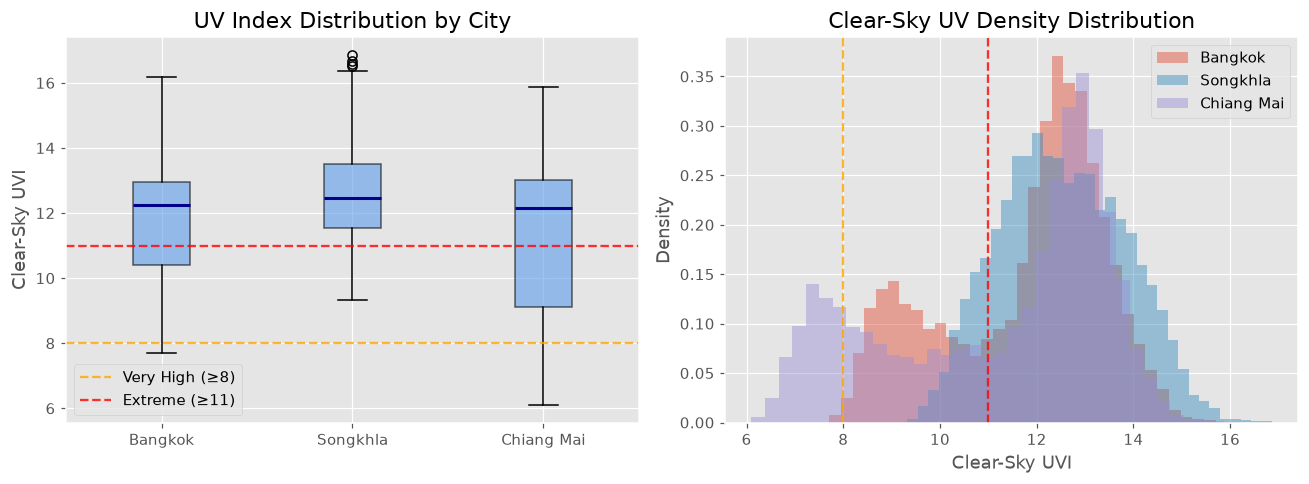

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Boxplot comparing cities
axes[0].boxplot(
    [eda_data[c]["uv"] for c in CITIES],
    tick_labels=[CITY_LABELS[c] for c in CITIES],
    patch_artist=True,
    boxprops=dict(facecolor="#5D9CEC", alpha=0.6),
    medianprops=dict(color="darkblue", lw=2),
)
axes[0].axhline(8, color="orange", linestyle="--", lw=1.5, alpha=0.8, label="Very High (≥8)")
axes[0].axhline(11, color="red", linestyle="--", lw=1.5, alpha=0.8, label="Extreme (≥11)")
axes[0].set_ylabel("Clear-Sky UVI")
axes[0].set_title("UV Index Distribution by City")
axes[0].legend(loc="lower left")

# Density histogram
for c in CITIES:
    uv = np.array(eda_data[c]["uv"])
    axes[1].hist(uv, bins=35, alpha=0.45, density=True, label=CITY_LABELS[c])
axes[1].axvline(8, color="orange", linestyle="--", lw=1.5, alpha=0.8)
axes[1].axvline(11, color="red", linestyle="--", lw=1.5, alpha=0.8)
axes[1].set_xlabel("Clear-Sky UVI")
axes[1].set_ylabel("Density")
axes[1].set_title("Clear-Sky UV Density Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

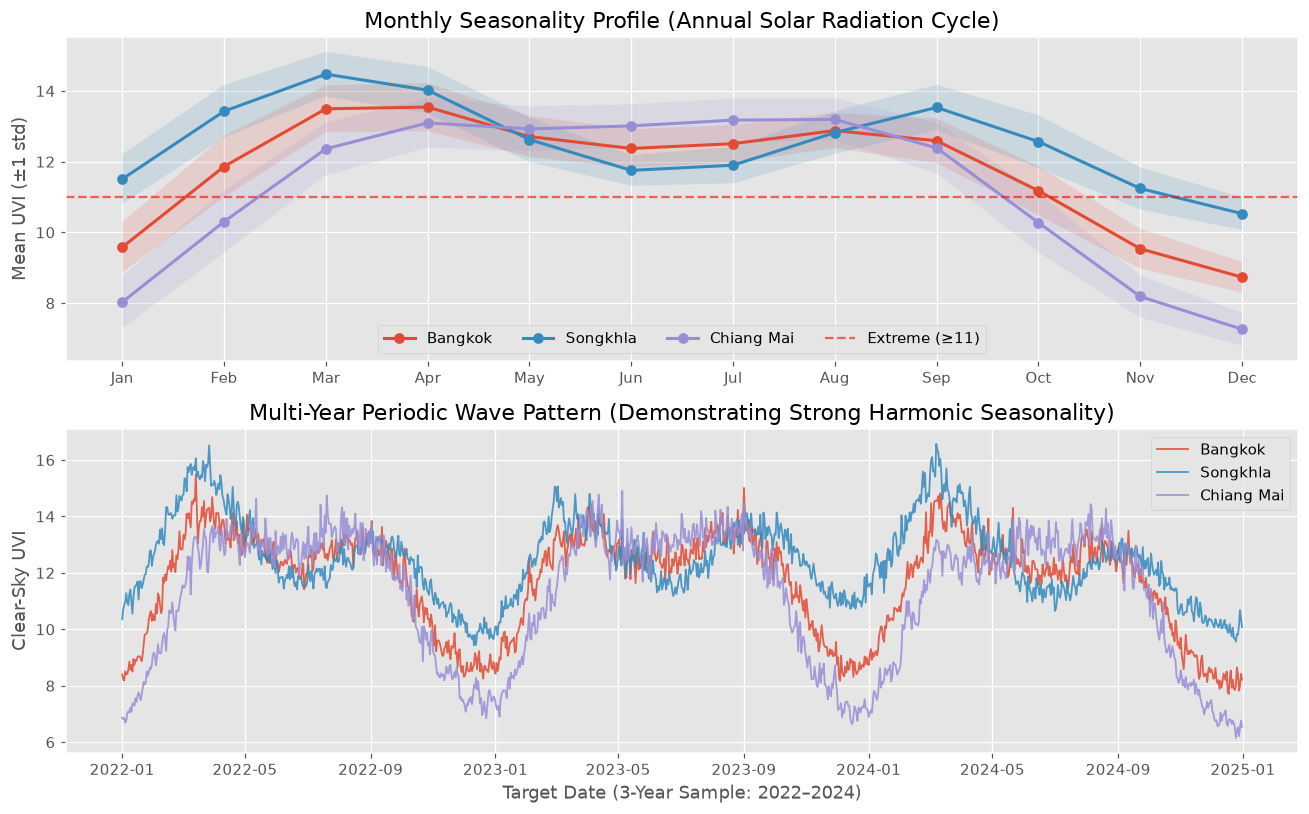

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7.5))

months = np.arange(1, 13)
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# 1. Monthly Seasonality Profile
for c in CITIES:
    uv = np.array(eda_data[c]["uv"])
    m = np.array(eda_data[c]["months"])
    mean_by_m = [uv[m == mo].mean() for mo in months]
    std_by_m = [uv[m == mo].std() for mo in months]
    axes[0].plot(months, mean_by_m, marker="o", label=CITY_LABELS[c], lw=2)
    axes[0].fill_between(
        months,
        np.array(mean_by_m) - np.array(std_by_m),
        np.array(mean_by_m) + np.array(std_by_m),
        alpha=0.15,
    )
axes[0].set_xticks(months)
axes[0].set_xticklabels(month_names)
axes[0].set_ylabel("Mean UVI (±1 std)")
axes[0].set_title("Monthly Seasonality Profile (Annual Solar Radiation Cycle)")
axes[0].axhline(11, color="red", linestyle="--", alpha=0.6, label="Extreme (≥11)")
axes[0].legend(loc="lower center", ncol=4)

# 2. Multi-Year Periodic Wave Pattern (Sample 2022-2024)
for c in CITIES:
    dates_c = eda_data[c]["dates"]
    uv_c = eda_data[c]["uv"]
    mask_sample = [date(2022, 1, 1) <= d <= date(2024, 12, 31) for d in dates_c]
    sample_dates = [d for d, m in zip(dates_c, mask_sample) if m]
    sample_uv = [u for u, m in zip(uv_c, mask_sample) if m]
    axes[1].plot(sample_dates, sample_uv, label=CITY_LABELS[c], lw=1.2, alpha=0.85)
axes[1].set_ylabel("Clear-Sky UVI")
axes[1].set_xlabel("Target Date (3-Year Sample: 2022–2024)")
axes[1].set_title("Multi-Year Periodic Wave Pattern (Demonstrating Strong Harmonic Seasonality)")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

### 2.1 Trend, Seasonality, Cyclic — แยกองค์ประกอบของอนุกรมเวลา

กราฟด้านบนแสดงรูปคลื่นแล้ว ส่วนนี้แยกอนุกรมออกเป็นองค์ประกอบอย่างเป็นทางการด้วย `seasonal_decompose` แบบบวก (คาบ 365 วัน) และวัดแนวโน้มเชิงปริมาณ 

วิธีวัด Trend ที่ถูกต้องสำหรับข้อมูลนี้คือ **ถอดฤดูกาลออกก่อนแล้วค่อยหาความชัน** เพราะถ้า regress ค่าดิบบนเวลาตรง ๆ ความชันจะขึ้นกับว่าอนุกรมเริ่มและจบที่เดือนใด (ชุดนี้เริ่ม 1 ก.ค. 2002) ตารางจึงรายงานความชันของ residual หลังถอด Fourier 2 harmonics ในหน่วย UVI ต่อทศวรรษ พร้อมค่า R² ที่บอกว่าฤดูกาลอธิบายความแปรปรวนทั้งหมดได้กี่ส่วน

### แนวโน้มระยะยาว
| City | Fourier R² | ความชันหลังถอดฤดูกาล (UVI/ทศวรรษ) | เฉลี่ย 365 วันแรก | เฉลี่ย 365 วันท้าย | ผลต่าง |
|---|---:|---:|---:|---:|---:|
| Bangkok | 0.896 | -0.0525 | 11.81 | 11.37 | -0.43 |
| Songkhla | 0.829 | -0.0841 | 12.64 | 12.06 | -0.58 |
| Chiang Mai | 0.935 | -0.0360 | 11.25 | 10.84 | -0.41 |

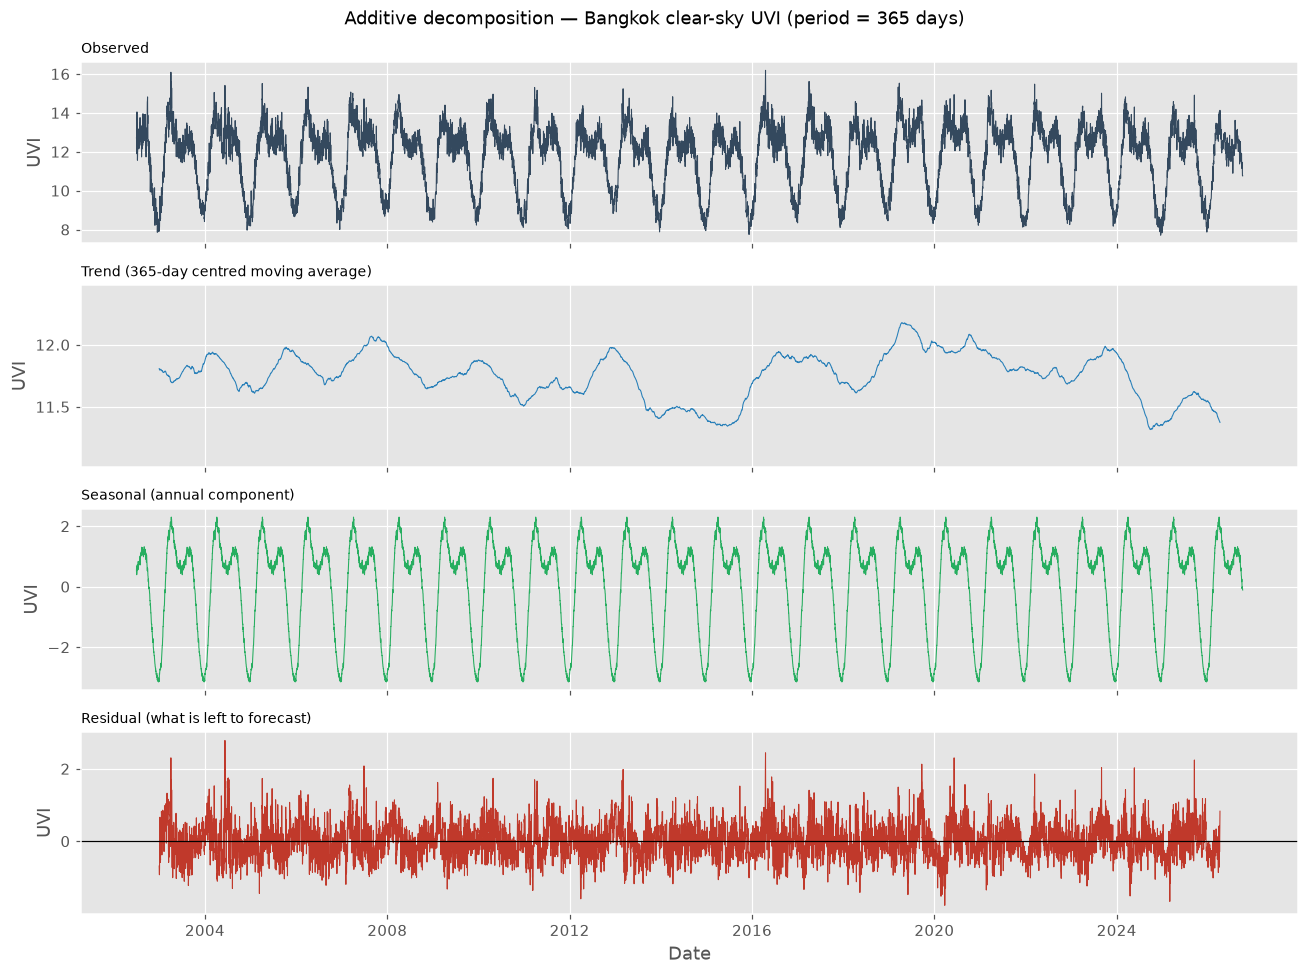

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf

uv_series = {}
for city in CITIES:
    days = eda_data[city]["dates"]
    if any((b - a).days != 1 for a, b in zip(days, days[1:])):
        raise ValueError(f"{city}: dates are not consecutive; index arithmetic below assumes a daily grid")
    uv_series[city] = (days, np.asarray(eda_data[city]["uv"], dtype=float))


def annual_fourier(days, harmonics=(1, 2)):
    """sin/cos ของคาบ 365.2425 วัน — ตัวแปรที่ทราบล่วงหน้าจากปฏิทินเพียงอย่างเดียว"""
    elapsed = np.array([day.toordinal() - date(2000, 1, 1).toordinal() for day in days], dtype=float)
    return np.column_stack(
        [function(2 * np.pi * harmonic * elapsed / 365.2425)
         for harmonic in harmonics for function in (np.sin, np.cos)]
    )


def deseasonalise(days, values):
    """ถอดฤดูกาลด้วย OLS บน Fourier 2 harmonics คืนค่า residual และสัดส่วนความแปรปรวนที่ฤดูกาลอธิบายได้"""
    design = np.column_stack([np.ones(len(values)), annual_fourier(days)])
    coefficients, *_ = np.linalg.lstsq(design, values, rcond=None)
    residual = values - design @ coefficients
    return residual, 1 - residual.var() / values.var()


trend_lines = [
    "| City | Fourier R² | ความชันหลังถอดฤดูกาล (UVI/ทศวรรษ) | เฉลี่ย 365 วันแรก | เฉลี่ย 365 วันท้าย | ผลต่าง |",
    "|---|---:|---:|---:|---:|---:|",
]
for city in CITIES:
    days, values = uv_series[city]
    residual, explained = deseasonalise(days, values)
    decades = np.arange(len(values)) / 3652.425
    slope = float(np.polyfit(decades, residual, 1)[0])
    trend_lines.append(
        f"| {CITY_LABELS[city]} | {explained:.3f} | {slope:+.4f} | {values[:365].mean():.2f} | "
        f"{values[-365:].mean():.2f} | {values[-365:].mean() - values[:365].mean():+.2f} |"
    )
display(Markdown("### แนวโน้มระยะยาว\n" + "\n".join(trend_lines)))

decomposition = seasonal_decompose(uv_series["bangkok"][1], period=365, model="additive")
panels = (
    ("Observed", uv_series["bangkok"][1], "#34495e"),
    ("Trend (365-day centred moving average)", decomposition.trend, "#2980b9"),
    ("Seasonal (annual component)", decomposition.seasonal, "#27ae60"),
    ("Residual (what is left to forecast)", decomposition.resid, "#c0392b"),
)
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
for ax, (title, component, colour) in zip(axes, panels):
    ax.plot(uv_series["bangkok"][0], component, lw=0.7, color=colour)
    ax.set_ylabel("UVI")
    ax.set_title(title, fontsize=9, loc="left")
axes[1].set_ylim(np.nanmin(decomposition.trend) - 0.3, np.nanmax(decomposition.trend) + 0.3)
axes[3].axhline(0, color="black", lw=0.8)
axes[-1].set_xlabel("Date")
fig.suptitle("Additive decomposition — Bangkok clear-sky UVI (period = 365 days)")
plt.tight_layout()
plt.show()

### 2.2 โครงสร้างสหสัมพันธ์ในตัวเอง (Autocorrelation) และวงรอบ (Cyclic)

ตรวจว่าอนุกรม "จำ" อดีตได้ยาวแค่ไหน และความจำนั้นเป็นฤดูกาลที่ทำนายได้จากปฏิทิน (Seasonality) หรือเป็นวงรอบที่ความยาวไม่คงที่ (Cyclic) 

- **Seasonality** คือคาบคงที่ 365 วันจากมุมตกกระทบของดวงอาทิตย์ — ACF ของค่าดิบจะมียอดคลื่นซ้ำที่ lag 365, 730 โดยแทบไม่ลดทอน
- **Cyclic** คือความผันผวนของปริมาณโอโซนและวัฏจักรสุริยะ (~11 ปี) ที่ไม่ผูกกับปฏิทิน — จะปรากฏเป็นความจำระยะสั้นที่เหลืออยู่ใน residual หลังถอดฤดูกาลออกแล้ว ซึ่งเป็นส่วนที่พจน์ AR/MA ของ SARIMAX รับผิดชอบ

PACF ของ residual ใช้เลือกอันดับของพจน์ AR: ถ้า PACF ตัดหลัง lag แรก ๆ แสดงว่า AR อันดับต่ำ (1–3) เพียงพอ ซึ่งตรงกับช่วง order ที่ส่วนที่ 4 นำมาทดลอง

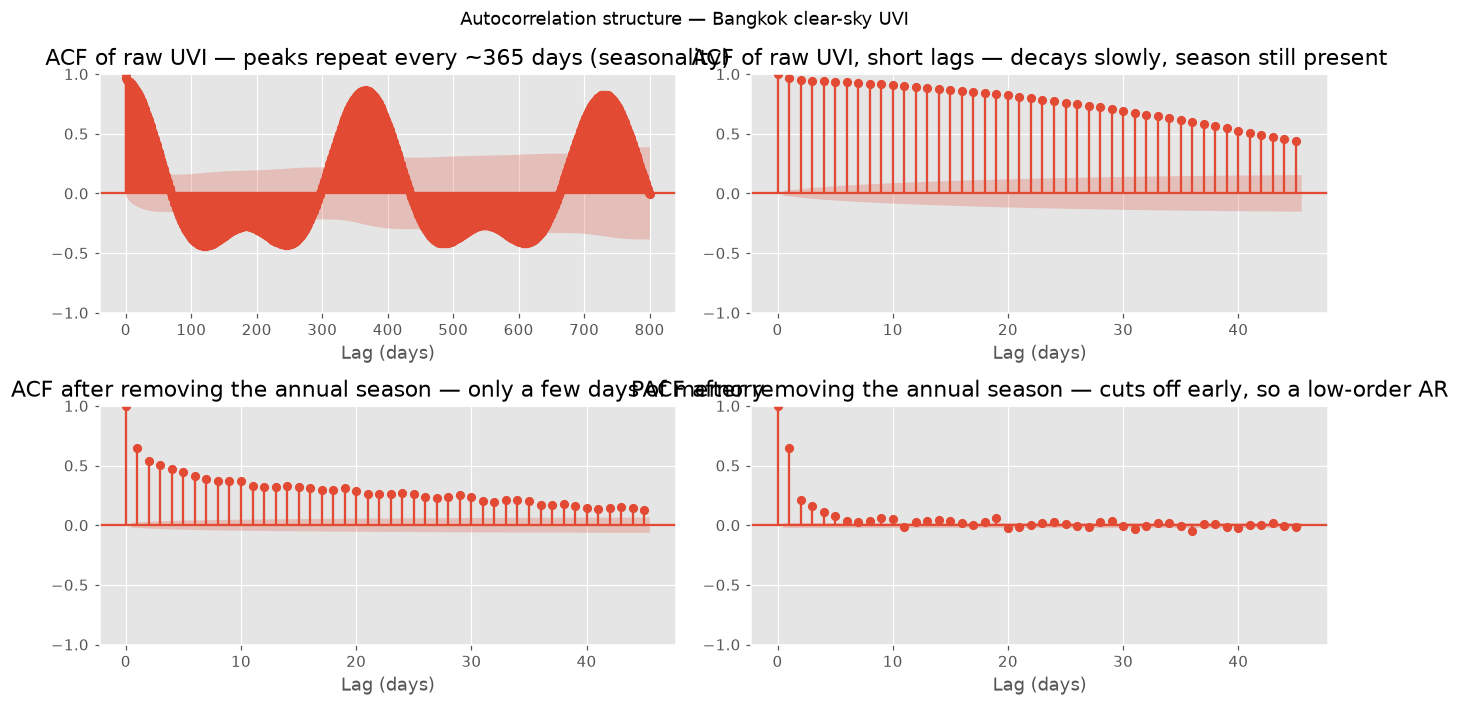

| City | ACF ค่าดิบ lag 1 | ACF ค่าดิบ lag 365 | ACF ค่าดิบ lag 730 | ACF residual lag 1 | ACF residual lag 7 |
|---|---:|---:|---:|---:|---:|
| Bangkok | 0.963 | 0.861 | 0.828 | 0.645 | 0.386 |
| Songkhla | 0.952 | 0.773 | 0.794 | 0.720 | 0.542 |
| Chiang Mai | 0.974 | 0.898 | 0.859 | 0.600 | 0.302 |

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(12, 6.5))
days, values = uv_series["bangkok"]
residual, _ = deseasonalise(days, values)

plot_acf(values, lags=800, ax=axes[0, 0], title="ACF of raw UVI — peaks repeat every ~365 days (seasonality)")
plot_acf(values, lags=45, ax=axes[0, 1], title="ACF of raw UVI, short lags — decays slowly, season still present")
plot_acf(residual, lags=45, ax=axes[1, 0], title="ACF after removing the annual season — only a few days of memory")
plot_pacf(residual, lags=45, ax=axes[1, 1], method="ywm",
          title="PACF after removing the annual season — cuts off early, so a low-order AR")
for ax in axes.ravel():
    ax.set_xlabel("Lag (days)")
fig.suptitle("Autocorrelation structure — Bangkok clear-sky UVI")
plt.tight_layout()
plt.show()

autocorrelation_lines = [
    "| City | ACF ค่าดิบ lag 1 | ACF ค่าดิบ lag 365 | ACF ค่าดิบ lag 730 | ACF residual lag 1 | ACF residual lag 7 |",
    "|---|---:|---:|---:|---:|---:|",
]
for city in CITIES:
    days, values = uv_series[city]
    residual, _ = deseasonalise(days, values)
    raw_acf = acf(values, nlags=730)
    residual_acf = acf(residual, nlags=7)
    autocorrelation_lines.append(
        f"| {CITY_LABELS[city]} | {raw_acf[1]:.3f} | {raw_acf[365]:.3f} | {raw_acf[730]:.3f} | "
        f"{residual_acf[1]:.3f} | {residual_acf[7]:.3f} |"
    )
display(Markdown("\n".join(autocorrelation_lines)))

### 2.3 การจัดการ Missing Value และ Outlier

TEMIS ใช้รหัส `-1` แทนวันที่ดาวเทียมไม่ให้ค่า ขั้นเตรียมข้อมูลในส่วนที่ 1 แปลงรหัสนี้เป็นค่าว่างแทนที่จะปล่อยให้เข้าสู่การคำนวณเป็นเลข −1 (ถ้าไม่แปลงจะกลายเป็น outlier เทียมที่รุนแรงมาก) ตารางด้านล่างนับค่าว่างที่เหลือ และตรวจว่าวันที่ในอนุกรมต่อเนื่องกันทุกวันหรือไม่ เพราะ SARIMAX ต้องการดัชนีเวลาที่ไม่มีช่องโหว่

สำหรับ outlier ค่าดิบของ UV **ไม่สามารถ** ใช้เกณฑ์ IQR ตรง ๆ ได้ เพราะค่าสูงในเดือนเมษายนเป็นเรื่องปกติ ไม่ใช่ความผิดปกติ จึงตรวจบน residual หลังถอดฤดูกาล (Fourier 2 harmonics) ออกก่อน แล้วค่อยวัดด้วย z-score และรั้ว IQR × 3

**การตัดสินใจ:** ไม่ลบหรือแทนค่า outlier ที่พบ เพราะ (ก) สัดส่วนน้อยกว่า 0.2% ของข้อมูล (ข) ค่าเหล่านี้คือวันที่โอโซนบางผิดปกติจริงตามการวัดของดาวเทียม ไม่ใช่ความผิดพลาดของเซนเซอร์ และ (ค) วันที่ UV สูงผิดปกติคือวันที่แอปจำเป็นต้องเตือนมากที่สุด การตัดทิ้งจะสอนให้โมเดลมองข้ามเหตุการณ์ที่สำคัญที่สุดต่อผู้ใช้

### ค่าว่าง (Missing Value)
| City | แถวทั้งหมด | ค่าว่างหลังแปลงรหัส -1 | สัดส่วน | ช่วงวันที่ขาดหาย |
|---|---:|---:|---:|---|
| Bangkok | 8,864 | 0 | 0.00% | ไม่มี (วันที่ต่อเนื่องทุกวัน) |
| Songkhla | 8,864 | 0 | 0.00% | ไม่มี (วันที่ต่อเนื่องทุกวัน) |
| Chiang Mai | 8,864 | 0 | 0.00% | ไม่มี (วันที่ต่อเนื่องทุกวัน) |

### ค่าผิดปกติ (Outlier) วัดบน residual หลังถอดฤดูกาลออกแล้ว
| City | SD ของ residual | \|z\| > 3 | \|z\| > 4 | นอกรั้ว IQR × 3 | วันที่เบี่ยงเบนมากที่สุด |
|---|---:|---:|---:|---:|---|
| Bangkok | 0.540 | 56 | 11 | 5 | 2004-06-09 (UVI 15.41, z = +5.8) |
| Songkhla | 0.536 | 29 | 2 | 1 | 2010-04-15 (UVI 16.87, z = +5.1) |
| Chiang Mai | 0.583 | 50 | 10 | 3 | 2007-07-04 (UVI 15.88, z = +4.9) |

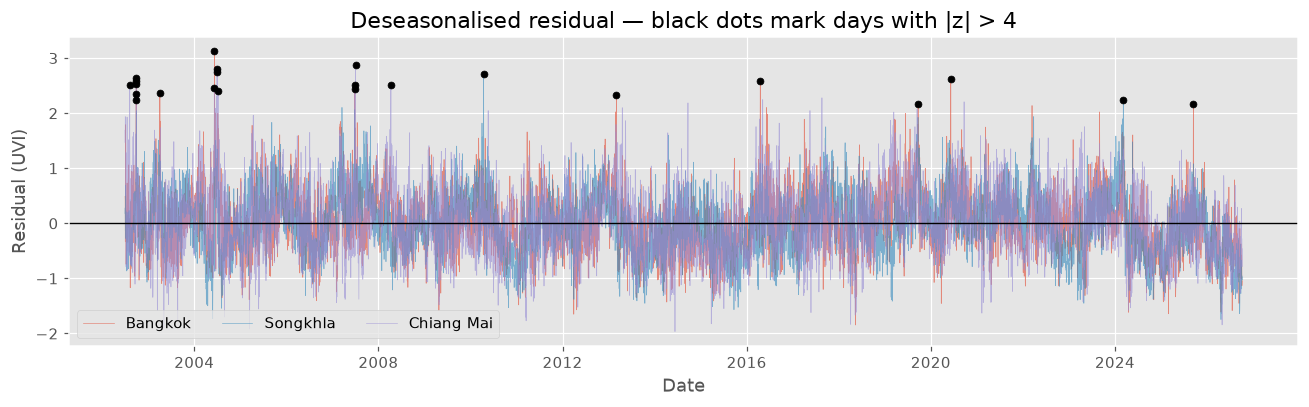

In [9]:
missing_counts = {city: 0 for city in CITIES}
row_counts = {city: 0 for city in CITIES}
with OUTPUT.open(newline="", encoding="utf-8") as file:
    for row in csv.DictReader(file):
        row_counts[row["city"]] += 1
        missing_counts[row["city"]] += not bool(row["uv_index_clear_sky"])

missing_lines = [
    "### ค่าว่าง (Missing Value)",
    "| City | แถวทั้งหมด | ค่าว่างหลังแปลงรหัส -1 | สัดส่วน | ช่วงวันที่ขาดหาย |",
    "|---|---:|---:|---:|---|",
]
for city in CITIES:
    days, _ = uv_series[city]
    gaps = [f"{a} → {b}" for a, b in zip(days, days[1:]) if (b - a).days != 1]
    missing_lines.append(
        f"| {CITY_LABELS[city]} | {row_counts[city]:,} | {missing_counts[city]} | "
        f"{missing_counts[city] / row_counts[city] * 100:.2f}% | "
        f"{'ไม่มี (วันที่ต่อเนื่องทุกวัน)' if not gaps else ', '.join(gaps[:3])} |"
    )

residuals = {}
outlier_lines = [
    "### ค่าผิดปกติ (Outlier) วัดบน residual หลังถอดฤดูกาลออกแล้ว",
    "| City | SD ของ residual | \\|z\\| > 3 | \\|z\\| > 4 | นอกรั้ว IQR × 3 | วันที่เบี่ยงเบนมากที่สุด |",
    "|---|---:|---:|---:|---:|---|",
]
for city in CITIES:
    days, values = uv_series[city]
    residual, _ = deseasonalise(days, values)
    residuals[city] = residual
    z_score = (residual - residual.mean()) / residual.std()
    first_quartile, third_quartile = np.percentile(residual, [25, 75])
    fence = 3 * (third_quartile - first_quartile)
    beyond_fence = int(((residual < first_quartile - fence) | (residual > third_quartile + fence)).sum())
    worst = int(np.argmax(np.abs(z_score)))
    outlier_lines.append(
        f"| {CITY_LABELS[city]} | {residual.std():.3f} | {int((np.abs(z_score) > 3).sum())} | "
        f"{int((np.abs(z_score) > 4).sum())} | {beyond_fence} | "
        f"{days[worst]} (UVI {values[worst]:.2f}, z = {z_score[worst]:+.1f}) |"
    )
display(Markdown("\n".join(missing_lines) + "\n\n" + "\n".join(outlier_lines)))

fig, ax = plt.subplots(figsize=(12, 3.8))
for city in CITIES:
    days, _ = uv_series[city]
    residual = residuals[city]
    z_score = (residual - residual.mean()) / residual.std()
    ax.plot(days, residual, lw=0.45, alpha=0.6, label=CITY_LABELS[city])
    flagged = np.abs(z_score) > 4
    ax.scatter(np.array(days, dtype=object)[flagged], residual[flagged], s=20, zorder=3, color="black")
ax.axhline(0, color="black", lw=0.9)
ax.set(title="Deseasonalised residual — black dots mark days with |z| > 4", ylabel="Residual (UVI)", xlabel="Date")
ax.legend(ncol=3, loc="lower left")
plt.tight_layout()
plt.show()

### ข้อสังเกตสำคัญจากการสำรวจข้อมูล (EDA Key Insights)

1. **ระดับความรุนแรงสูงเกือบตลอดปี:** ทั้ง 3 เมืองมีค่า Clear-sky UV อยู่ในเกณฑ์ **Very High (≥8)** และ **Extreme (≥11)** รวมกันมากกว่า 84% ถึง 100% ของจำนวนวันทั้งหมด โดยสงขลาอยู่ในระดับ Extreme สูงถึง 87.1%
2. **ความแตกต่างตามละติจูด (Latitude Variation):** 
   - **เชียงใหม่ (เหนือสุด ~18.8°N):** มีความแปรปรวนสูงสุด (Std = 2.28) และมีค่าลดต่ำลงอย่างชัดเจนในฤดูหนาว (พ.ย. – ม.ค.) ลงไปแตะระดับ High (6–8) ประมาณ 15.4%
   - **สงขลา (ใต้สุด ~7.2°N):** มีความแปรปรวนต่ำสุด (Std = 1.30) และมีค่าเฉลี่ยสูงสุด (Mean = 12.53) โดยมีลักษณะ Double-peak (ยอดคลื่น 2 ครั้งต่อปี) ตามระนาบดวงอาทิตย์ตั้งฉาก
3. **Seasonality เป็นองค์ประกอบหลักและทำนายได้จากปฏิทิน:** Fourier 2 harmonics อธิบายความแปรปรวนได้ **0.84–0.94** (เชียงใหม่สูงสุดที่ R² ≈ 0.935 สงขลาต่ำสุดที่ ≈ 0.840 เพราะรูปคลื่น double-peak ซับซ้อนกว่า) ACF ของค่าดิบยังมียอดคลื่นชัดเจนที่ lag 365 และ 730 โดยไม่ลดทอน ยืนยันว่าคาบคงที่จริง ไม่ใช่คาบที่ลอยไปมา จึงใช้ **Fourier Series (2 Harmonics, คาบ 365.2425 วัน)** เป็นตัวแทนฤดูกาลใน SARIMAX ได้โดยไม่ต้องใช้พจน์ seasonal AR/MA ที่ lag 365 ซึ่งมีต้นทุนการประมาณค่าสูงมาก
4. **Trend ระยะยาวแทบไม่มี:** ความชันหลังถอดฤดูกาลอยู่ที่ประมาณ **−0.04 ถึง −0.08 UVI ต่อทศวรรษ** หรือราว −0.3% ถึง −0.7% ต่อทศวรรษ ซึ่งเล็กกว่าความคลาดเคลื่อนรายวันของโมเดล (MAE ≈ 0.3 UVI) หลายเท่า จึงไม่จำเป็นต้องใส่พจน์แนวโน้มเชิงเส้นเข้าโมเดล และสอดคล้องกับการฟื้นตัวของชั้นโอโซนอย่างช้า ๆ หลังพิธีสารมอนทรีออล
5. **Cyclic คือส่วนที่เหลือให้โมเดลทำงาน:** หลังถอดฤดูกาลออก residual ยังมี ACF ที่ lag 1 ประมาณ **0.59–0.70** และลดลงเหลือ ~0.43–0.59 ที่ lag 3 นี่คือความผันผวนของปริมาณโอโซนและเมฆชั้นบนที่กินเวลาไม่กี่วัน ไม่ผูกกับปฏิทิน และเป็น**ส่วนเดียวที่พจน์ AR/MA ของ SARIMAX จะเอาชนะ baseline ตามฤดูกาลได้** ถ้าไม่มีความจำส่วนนี้ โมเดลก็จะไม่ต่างจากการเปิดตารางค่าเฉลี่ยรายวัน
6. **คุณภาพข้อมูลดีมาก:** ไม่มีค่าว่างและไม่มีวันที่ขาดหายในชุดปัจจุบัน (8,864 วันต่อเมือง ต่อเนื่องตั้งแต่ 1 ก.ค. 2002) ค่าผิดปกติที่ |z| > 4 บน residual มีเพียง 2–11 วันต่อเมือง (< 0.13%) และเป็นเหตุการณ์โอโซนบางจริง จึงเก็บไว้ทั้งหมด

## 3. การเตรียมข้อมูลก่อนสร้างโมเดล (Data Preprocessing)

ส่วนนี้ตอบคำถามที่ต้องตอบก่อนเลือกโครงสร้างโมเดล 3 ข้อ

1. **อนุกรมนิ่ง (stationary) หรือไม่** — ทดสอบด้วย Augmented Dickey-Fuller (ADF) และยืนยันซ้ำด้วย KPSS ที่มีสมมติฐานหลักกลับทางกัน
2. **ต้องทำ Differencing หรือไม่** — ถ้าต้อง ต้องกี่ครั้ง และถ้าไม่ต้อง ต้องแสดงหลักฐานว่าการทำจะทำให้แย่ลง
3. **แบ่งข้อมูลอย่างไร** — ช่วงไหนใช้ฝึก ช่วงไหนใช้เลือกโมเดล ช่วงไหนห้ามแตะจนกว่าจะรายงานผล

### 3.1 ทดสอบ Stationarity

การทดสอบทั้งหมดทำบน **ชุดฝึกเท่านั้น (ถึง 2023-12-31)** เพราะถ้าใช้ทั้งอนุกรมมาตัดสินโครงสร้างโมเดล ข้อมูลของชุดทดสอบจะรั่วเข้าสู่การตัดสินใจทางการออกแบบ

ทดสอบ 3 อนุกรมเพื่อแยกแยะว่าความ "ไม่นิ่ง" (ถ้ามี) มาจากฤดูกาลหรือจาก unit root จริง — ค่าดิบ, residual หลังถอดฤดูกาลด้วย Fourier, และอนุกรมหลัง differencing 1 ครั้ง

In [10]:
"""Stationarity diagnostics — computed on the training window only, never on validation or test."""

import warnings

from statsmodels.tsa.stattools import adfuller, kpss

TRAIN_END = date(2023, 12, 31)
VALID_END = date(2024, 12, 31)

stationarity_lines = [
    "| City | อนุกรมที่ทดสอบ | ADF statistic | ADF p-value | สรุปจาก ADF | KPSS statistic | KPSS p-value | สรุปจาก KPSS |",
    "|---|---|---:|---:|---|---:|---:|---|",
]
for city in CITIES:
    days, values = uv_series[city]
    stop = next(index for index, day in enumerate(days) if day > TRAIN_END)
    train_days, train_values = days[:stop], values[:stop]
    residual, _ = deseasonalise(train_days, train_values)
    candidates = (
        ("ค่าดิบ (level)", train_values),
        ("หลังถอดฤดูกาลด้วย Fourier", residual),
        ("หลัง Differencing ครั้งที่ 1 (d=1)", np.diff(train_values)),
    )
    for label, candidate in candidates:
        with warnings.catch_warnings():
            # statsmodels 0.15 warns that both helpers will return result objects in 0.16,
            # and KPSS warns again when p falls outside its lookup table.
            warnings.simplefilter("ignore")
            adf_statistic, adf_p, *_ = adfuller(candidate, autolag="AIC")
            kpss_statistic, kpss_p, *_ = kpss(candidate, regression="c", nlags="auto")
        stationarity_lines.append(
            f"| {CITY_LABELS[city]} | {label} | {adf_statistic:.2f} | {adf_p:.2e} | "
            f"{'นิ่ง (ปฏิเสธ unit root)' if adf_p < 0.05 else 'ไม่นิ่ง'} | "
            f"{kpss_statistic:.3f} | {kpss_p:.3f} | "
            f"{'นิ่ง (ไม่ปฏิเสธ H₀)' if kpss_p >= 0.05 else 'ไม่นิ่ง'} |"
        )
display(Markdown(
    "### ผลการทดสอบ Stationarity (คำนวณจากชุดฝึกเท่านั้น)\n"
    "> **ADF** — H₀ คือ *มี* unit root (ไม่นิ่ง) ดังนั้น p ต่ำ = นิ่ง  \n"
    "> **KPSS** — H₀ คือ *นิ่ง* ดังนั้น p สูง = นิ่ง สองการทดสอบมีสมมติฐานกลับทางกัน จึงใช้ยืนยันซึ่งกันและกัน\n\n"
    + "\n".join(stationarity_lines)
))

### ผลการทดสอบ Stationarity (คำนวณจากชุดฝึกเท่านั้น)
> **ADF** — H₀ คือ *มี* unit root (ไม่นิ่ง) ดังนั้น p ต่ำ = นิ่ง  
> **KPSS** — H₀ คือ *นิ่ง* ดังนั้น p สูง = นิ่ง สองการทดสอบมีสมมติฐานกลับทางกัน จึงใช้ยืนยันซึ่งกันและกัน

| City | อนุกรมที่ทดสอบ | ADF statistic | ADF p-value | สรุปจาก ADF | KPSS statistic | KPSS p-value | สรุปจาก KPSS |
|---|---|---:|---:|---|---:|---:|---|
| Bangkok | ค่าดิบ (level) | -12.24 | 1.01e-22 | นิ่ง (ปฏิเสธ unit root) | 0.018 | 0.100 | นิ่ง (ไม่ปฏิเสธ H₀) |
| Bangkok | หลังถอดฤดูกาลด้วย Fourier | -9.35 | 8.29e-16 | นิ่ง (ปฏิเสธ unit root) | 0.428 | 0.065 | นิ่ง (ไม่ปฏิเสธ H₀) |
| Bangkok | หลัง Differencing ครั้งที่ 1 (d=1) | -8.95 | 8.74e-15 | นิ่ง (ปฏิเสธ unit root) | 0.008 | 0.100 | นิ่ง (ไม่ปฏิเสธ H₀) |
| Songkhla | ค่าดิบ (level) | -16.19 | 4.23e-29 | นิ่ง (ปฏิเสธ unit root) | 0.028 | 0.100 | นิ่ง (ไม่ปฏิเสธ H₀) |
| Songkhla | หลังถอดฤดูกาลด้วย Fourier | -7.30 | 1.34e-10 | นิ่ง (ปฏิเสธ unit root) | 0.277 | 0.100 | นิ่ง (ไม่ปฏิเสธ H₀) |
| Songkhla | หลัง Differencing ครั้งที่ 1 (d=1) | -9.43 | 5.15e-16 | นิ่ง (ปฏิเสธ unit root) | 0.005 | 0.100 | นิ่ง (ไม่ปฏิเสธ H₀) |
| Chiang Mai | ค่าดิบ (level) | -10.41 | 1.78e-18 | นิ่ง (ปฏิเสธ unit root) | 0.015 | 0.100 | นิ่ง (ไม่ปฏิเสธ H₀) |
| Chiang Mai | หลังถอดฤดูกาลด้วย Fourier | -8.47 | 1.52e-13 | นิ่ง (ปฏิเสธ unit root) | 0.548 | 0.031 | ไม่นิ่ง |
| Chiang Mai | หลัง Differencing ครั้งที่ 1 (d=1) | -8.54 | 9.63e-14 | นิ่ง (ปฏิเสธ unit root) | 0.011 | 0.100 | นิ่ง (ไม่ปฏิเสธ H₀) |

### 3.2 ทำ Differencing หรือไม่

ผลจาก 3.1: **ADF ปฏิเสธ unit root ที่ p ≈ 1e-18 หรือต่ำกว่าทุกเมือง ตั้งแต่ค่าดิบ** และ KPSS ไม่ปฏิเสธความนิ่งของค่าดิบ (p ≥ 0.1 ทุกเมือง) ทั้งสองการทดสอบที่มีสมมติฐานกลับทางกันเห็นตรงกันว่าอนุกรม **ไม่มี unit root และไม่ต้องทำ differencing**

(ข้อสังเกตเดียวที่ไม่ลงรอย: KPSS ของ residual เชียงใหม่ให้ p = 0.031 ซึ่งปฏิเสธความนิ่งอย่างอ่อน ๆ นี่คือร่องรอยของแนวโน้มลดลงช้า ๆ ที่ส่วนที่ 2.1 วัดได้ที่ −0.036 UVI ต่อทศวรรษ ซึ่งเล็กเกินกว่าจะกระทบ การพยากรณ์ล่วงหน้า 2 วัน และที่สำคัญคือมัน**ไม่ใช่ unit root** — ADF ยังปฏิเสธที่ p = 1.5e-13 จึงแก้ด้วย differencing ไม่ได้และไม่ควรแก้) ผลนี้ตรงกับฟิสิกส์ของข้อมูล: UV ที่ท้องฟ้าโปร่งถูกตรึงด้วยเรขาคณิตของวงโคจรโลก มันแกว่งรอบค่าเฉลี่ยที่กำหนดโดยปฏิทิน ไม่ใช่ random walk ที่ลอยไปได้ไม่จำกัด

เซลล์ถัดไปแสดงหลักฐานว่าการ differencing จะ**เสียมากกว่าได้**:

- **สัญญาณถูกทำลาย** ค่า SD หลัง d=1 ไม่ได้เล็กกว่าค่า SD หลังถอดฤดูกาลด้วย Fourier อย่างมีนัย แปลว่า differencing ไม่ได้ช่วยลดความผันผวนที่ต้องทำนาย แต่ทำให้อนุกรมเป็นผลต่างรายวันที่แทบไม่มีโครงสร้าง
- **ACF ที่ lag 1 กลายเป็นค่าลบราว −0.35** นี่คือลายเซ็นคลาสสิกของ over-differencing (differencing อนุกรมที่นิ่งอยู่แล้วจะใส่ค่า MA(1) ลบเทียมเข้าไป) ทำให้ต้องเพิ่มพจน์ MA มาแก้สิ่งที่ตัวเองสร้างขึ้น
- **เสียความสามารถในการพยากรณ์ระดับ** โมเดลบนอนุกรมที่ differencing แล้วจะพยากรณ์ *การเปลี่ยนแปลง* ซึ่งเมื่อสะสมกลับเป็นระดับจะได้ช่วงความเชื่อมั่นที่กว้างขึ้นเรื่อย ๆ ขณะที่แอปต้องการระดับ UVI ที่แน่นอนเพื่อเทียบกับเกณฑ์ 8 และ 11

**ข้อสรุป: ใช้ d = 0 และจัดการฤดูกาลด้วย Fourier regressors แทน** ซึ่งเป็นค่าที่ส่วนที่ 4 ใช้จริงใน `ORDERS = ((1,0,0), (2,0,0), (3,0,0), (1,0,1))` — ทุก order มี d = 0

### เปรียบเทียบการถอดฤดูกาลด้วย Fourier กับการทำ Differencing
| City | SD ค่าดิบ | SD หลังถอดฤดูกาล | SD หลัง d=1 | ACF lag 1 หลังถอดฤดูกาล | ACF lag 1 หลัง d=1 |
|---|---:|---:|---:|---:|---:|
| Bangkok | 1.685 | 0.533 | 0.461 | +0.629 | -0.348 |
| Songkhla | 1.295 | 0.518 | 0.404 | +0.698 | -0.347 |
| Chiang Mai | 2.293 | 0.584 | 0.533 | +0.587 | -0.340 |

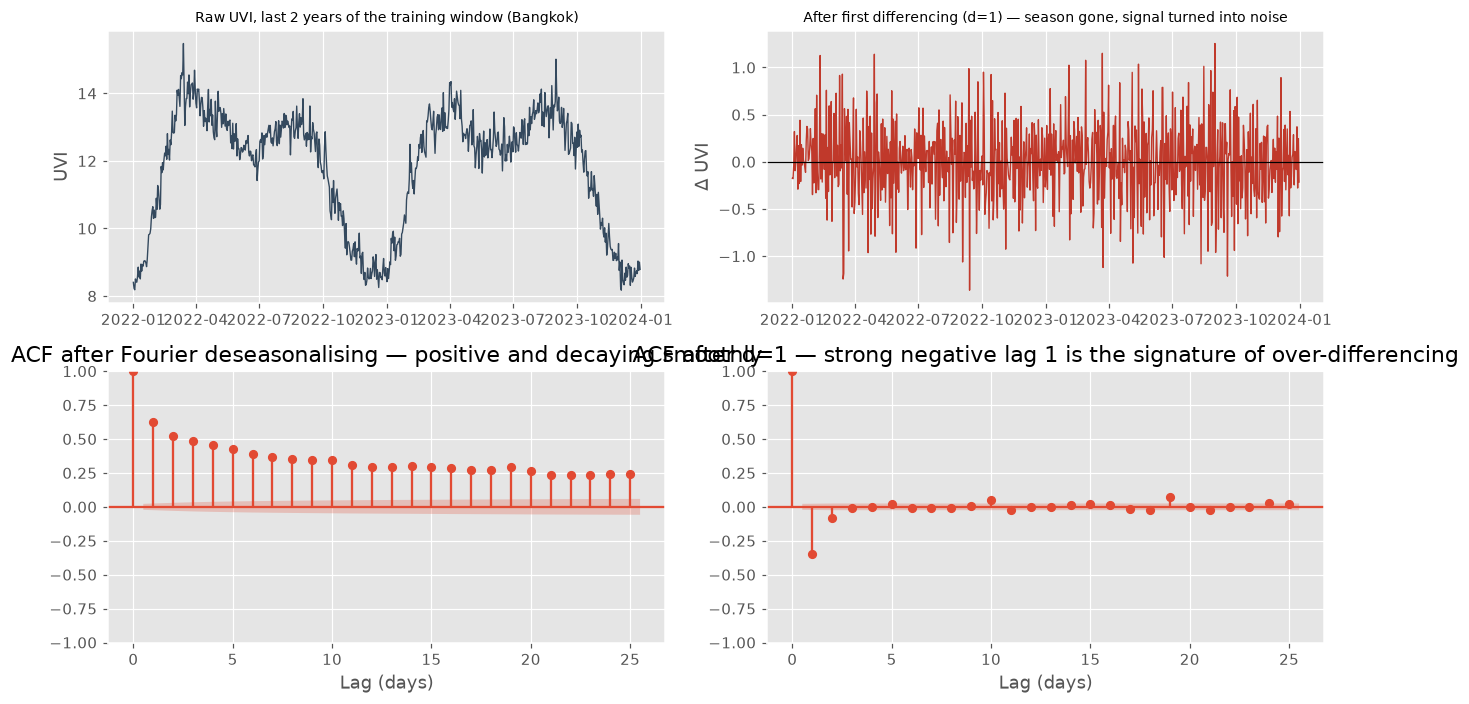

In [11]:
differencing_lines = [
    "| City | SD ค่าดิบ | SD หลังถอดฤดูกาล | SD หลัง d=1 | ACF lag 1 หลังถอดฤดูกาล | ACF lag 1 หลัง d=1 |",
    "|---|---:|---:|---:|---:|---:|",
]
for city in CITIES:
    days, values = uv_series[city]
    stop = next(index for index, day in enumerate(days) if day > TRAIN_END)
    train_days, train_values = days[:stop], values[:stop]
    residual, _ = deseasonalise(train_days, train_values)
    differenced = np.diff(train_values)
    differencing_lines.append(
        f"| {CITY_LABELS[city]} | {train_values.std():.3f} | {residual.std():.3f} | {differenced.std():.3f} | "
        f"{acf(residual, nlags=1)[1]:+.3f} | {acf(differenced, nlags=1)[1]:+.3f} |"
    )
display(Markdown("### เปรียบเทียบการถอดฤดูกาลด้วย Fourier กับการทำ Differencing\n"
                 + "\n".join(differencing_lines)))

days, values = uv_series["bangkok"]
stop = next(index for index, day in enumerate(days) if day > TRAIN_END)
window = slice(stop - 730, stop)
residual, _ = deseasonalise(days[:stop], values[:stop])
differenced = np.diff(values[:stop])

fig, axes = plt.subplots(2, 2, figsize=(12, 6.5))
axes[0, 0].plot(days[window], values[window], lw=0.9, color="#34495e")
axes[0, 0].set_title("Raw UVI, last 2 years of the training window (Bangkok)", fontsize=9)
axes[0, 0].set_ylabel("UVI")
axes[0, 1].plot(days[window], differenced[window.start - 1:window.stop - 1], lw=0.9, color="#c0392b")
axes[0, 1].axhline(0, color="black", lw=0.8)
axes[0, 1].set_title("After first differencing (d=1) — season gone, signal turned into noise", fontsize=9)
axes[0, 1].set_ylabel("Δ UVI")
plot_acf(residual, lags=25, ax=axes[1, 0], title="ACF after Fourier deseasonalising — positive and decaying smoothly")
plot_acf(differenced, lags=25, ax=axes[1, 1],
         title="ACF after d=1 — strong negative lag 1 is the signature of over-differencing")
for ax in axes[1]:
    ax.set_xlabel("Lag (days)")
plt.tight_layout()
plt.show()

### 3.3 การแบ่ง Train / Validation / Test

**แบ่งตามลำดับเวลา ไม่สุ่ม** การสุ่มแบบ 80:20 ทั่วไปใช้ไม่ได้กับอนุกรมเวลา เพราะถ้าวันที่ 2 ม.ค. ไปอยู่ในชุดฝึกขณะที่ 1 ม.ค. และ 3 ม.ค. อยู่ในชุดทดสอบ โมเดลจะเห็น "อนาคต" ของจุดที่ต้องทำนาย (data leakage) และคะแนนที่ได้จะดีเกินจริงจนไร้ความหมาย

**ใช้ 3 ชุดแทน 2 ชุด** เพราะต้องเลือก order ของ SARIMAX และไฮเปอร์พารามิเตอร์ของโมเดลเปรียบเทียบ ถ้าเลือกบนชุดทดสอบ คะแนนสุดท้ายจะกลายเป็นคะแนนของผู้ชนะที่ถูกคัดมาแล้ว (selection bias) จึงกันชุด validation (ปี 2024) ไว้สำหรับการเลือกโดยเฉพาะ และแตะชุด test (ปี 2025 เป็นต้นไป) เพียงครั้งเดียวตอนรายงานผล

**ทำไมสัดส่วนไม่ใช่ 80:20** เพราะข้อมูลยาว 24 ปี การตัด 20% ท้ายเป็นชุดทดสอบจะได้ชุดทดสอบยาวเกือบ 5 ปี และเหลือข้อมูลฝึกที่จบลงตั้งแต่ปี 2021 ซึ่งทำให้โมเดลที่นำไปใช้จริงล้าสมัย สำหรับงานพยากรณ์ล่วงหน้า 2 วัน ชุดทดสอบที่กันไว้ 644 วัน (ซึ่งมีผลพยากรณ์ล่วงหน้า 2 วันให้ประเมินจริง 635 วัน ครอบคลุมครบทุกเดือนเกือบ 2 รอบปี) ให้ค่าคลาดเคลื่อนมาตรฐานของ MAE ที่แคบพอแล้ว การขยายชุดทดสอบต่อไปจึงแลกความแม่นของการวัดกับความสดของโมเดลโดยไม่คุ้ม — สัดส่วนที่ได้จึงเป็นประมาณ **88.6 : 4.1 : 7.3**

### การแบ่งข้อมูลแบบลำดับเวลา (Chronological Split)
| Split | ช่วงวันที่ | จำนวนวันต่อเมือง | สัดส่วน | หน้าที่ |
|---|---|---:|---:|---|
| Train | 2002-07-01 → 2023-12-31 | 7,854 | 88.6% | ประมาณค่าพารามิเตอร์ของโมเดล |
| Validation | 2024-01-01 → 2024-12-31 | 366 | 4.1% | เลือก order ของ SARIMAX และไฮเปอร์พารามิเตอร์ของโมเดลเปรียบเทียบ |
| Test (hold-out) | 2025-01-01 → 2026-10-06 | 644 | 7.3% | วัดผลครั้งเดียวตอนท้าย ไม่ใช้ตัดสินใจใด ๆ |
| **รวม** | 2002-07-01 → 2026-10-06 | **8,864** | 100.0% | |

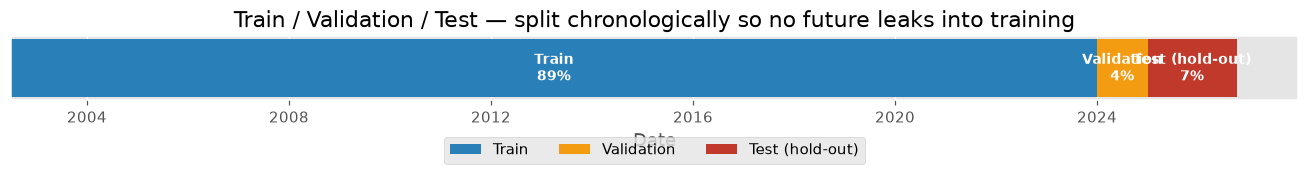

In [12]:
reference_days, _ = uv_series["bangkok"]
train_stop = next(index for index, day in enumerate(reference_days) if day > TRAIN_END)
valid_stop = next(index for index, day in enumerate(reference_days) if day > VALID_END)
total_days = len(reference_days)

SPLITS = (
    ("Train", 0, train_stop, "ประมาณค่าพารามิเตอร์ของโมเดล"),
    ("Validation", train_stop, valid_stop, "เลือก order ของ SARIMAX และไฮเปอร์พารามิเตอร์ของโมเดลเปรียบเทียบ"),
    ("Test (hold-out)", valid_stop, total_days, "วัดผลครั้งเดียวตอนท้าย ไม่ใช้ตัดสินใจใด ๆ"),
)
split_lines = ["| Split | ช่วงวันที่ | จำนวนวันต่อเมือง | สัดส่วน | หน้าที่ |", "|---|---|---:|---:|---|"]
for name, start, stop, purpose in SPLITS:
    split_lines.append(
        f"| {name} | {reference_days[start]} → {reference_days[stop - 1]} | {stop - start:,} | "
        f"{(stop - start) / total_days * 100:.1f}% | {purpose} |"
    )
split_lines.append(f"| **รวม** | {reference_days[0]} → {reference_days[-1]} | **{total_days:,}** | 100.0% | |")
display(Markdown("### การแบ่งข้อมูลแบบลำดับเวลา (Chronological Split)\n" + "\n".join(split_lines)))

fig, ax = plt.subplots(figsize=(12, 2.2))
colours = ("#2980b9", "#f39c12", "#c0392b")
for (name, start, stop, _), colour in zip(SPLITS, colours):
    ax.barh(0, (reference_days[stop - 1] - reference_days[start]).days + 1,
            left=reference_days[start], height=0.5, color=colour, label=name)
    midpoint = reference_days[start] + (reference_days[stop - 1] - reference_days[start]) / 2
    ax.text(midpoint, 0, f"{name}\n{(stop - start) / total_days * 100:.0f}%",
            ha="center", va="center", color="white", fontsize=9, fontweight="bold")
ax.set_yticks([])
ax.set_xlabel("Date")
ax.set_title("Train / Validation / Test — split chronologically so no future leaks into training")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.45), ncol=3)
plt.tight_layout()
plt.show()

## 4. ฝึก SARIMAX ในเครื่อง

โค้ดที่รวมจาก `scripts/train_uv_model.py` สร้าง Fourier sine/cosine สอง harmonic ต่อปี (4 ตัวแปรที่ทราบจากวันที่), ทดลอง order `(1,0,0)`, `(2,0,0)`, `(3,0,0)`, `(1,0,1)` สำหรับแต่ละเมือง แล้วเลือกจาก MAE ของการทำนายล่วงหน้า 2 วันใน validation ปี 2024 ข้อมูลถึง 2023-12-31 ใช้ฝึก และปี 2025 เป็นต้นไปกันเป็น test การ backtest เดินทีละวันโดยใช้ค่าจริงที่มีถึงจุดพยากรณ์เท่านั้น

ทุก order มี `d = 0` ตามข้อสรุปของส่วนที่ 3 และช่วงอันดับ AR ที่ 1–3 มาจากรูป PACF ในส่วนที่ 2.2 ที่ตัดลงหลัง lag แรก ๆ

`train_uv_models()` จะฝึกและบันทึกไฟล์ `.pkl` หากมีคน **เรียกฟังก์ชันนี้เอง** เท่านั้น รอบนี้ไม่มีเซลล์ใดเรียกมัน โค้ด production อยู่ในสคริปต์ต้นทาง ซึ่งเป็นแหล่งอ้างอิงเมื่อแก้ไขระบบจริง

In [13]:
"""Backtest and locally train clear-sky UV SARIMAX models for three cities."""

import csv
import hashlib
import json
import math
from datetime import date, timedelta
from pathlib import Path

import numpy as np
import statsmodels
from statsmodels.tsa.statespace.sarimax import SARIMAX


DATA = ROOT / "storage/data/uv/temis_clear_sky_uv.csv"
ARTIFACTS = ROOT / "storage/artifacts/uv"
MODELS = ROOT / "storage/models/uv"
CITIES = ("bangkok", "songkhla", "chiang_mai")
ORDERS = ((1, 0, 0), (2, 0, 0), (3, 0, 0), (1, 0, 1))
TRAIN_END = date(2023, 12, 31)
VALID_END = date(2024, 12, 31)


def load_data():
    series = {city: ([], []) for city in CITIES}
    with DATA.open(newline="", encoding="utf-8") as file:
        for row in csv.DictReader(file):
            city = row["city"]
            if city not in series:
                raise ValueError(f"Unknown city: {city}")
            day = date.fromisoformat(row["date"])
            if not row["uv_index_clear_sky"]:
                raise ValueError(f"Missing UV value: {city} {day}; resolve before training")
            uv = float(row["uv_index_clear_sky"])
            if not math.isfinite(uv) or uv < 0:
                raise ValueError(f"Invalid UV value: {city} {day}")
            days, values = series[city]
            if days and day != days[-1] + timedelta(days=1):
                raise ValueError(f"Nonconsecutive date: {city} {day}")
            days.append(day)
            values.append(uv)
    for city, (days, _) in series.items():
        if not days or days[0] > TRAIN_END or days[-1] <= VALID_END:
            raise ValueError(f"Insufficient date range: {city}")
    return series


def fourier(days):
    elapsed = np.array([day.toordinal() - date(2000, 1, 1).toordinal() for day in days])
    return np.column_stack(
        [function(2 * np.pi * harmonic * elapsed / 365.2425)
         for harmonic in (1, 2) for function in (np.sin, np.cos)]
    )


def fit_model(values, features, order):
    result = SARIMAX(
        values, exog=features, order=order, trend="c", enforce_stationarity=True
    ).fit(disp=False, maxiter=100)
    if not result.mle_retvals.get("converged"):
        raise RuntimeError("SARIMAX optimization did not converge")
    return result


def rolling_forecasts(result, days, values, features, start, stop):
    """Each prediction uses only observations through its forecast origin."""
    one_day = np.empty(stop - start)
    two_days = np.full(stop - start, np.nan)
    for offset, index in enumerate(range(start, stop)):
        future = (days[index], days[index] + timedelta(days=1))
        predicted = result.get_forecast(steps=2, exog=fourier(future)).predicted_mean
        one_day[offset] = predicted[0]
        if offset + 1 < len(two_days):
            two_days[offset + 1] = predicted[1]
        result = result.extend(values[index:index + 1], exog=features[index:index + 1])
    return one_day, two_days


def seasonal_baseline(days, values, start, stop):
    known = dict(zip(days, values, strict=True))
    predicted = []
    for day in days[start:stop]:
        try:
            previous_year = day.replace(year=day.year - 1)
        except ValueError:  # 29 February
            previous_year = day.replace(year=day.year - 1, day=28)
        predicted.append(known[previous_year])
    return np.array(predicted)


def score(actual, predicted):
    mask = np.isfinite(predicted)
    error = actual[mask] - predicted[mask]
    return {"n": int(mask.sum()), "mae": round(float(np.mean(np.abs(error))), 4),
            "rmse": round(float(np.sqrt(np.mean(error ** 2))), 4)}


def train_uv_models():
    series = load_data()
    data_hash = hashlib.sha256(DATA.read_bytes()).hexdigest()
    summary = {"source_sha256": data_hash, "model": "SARIMAX + 2 annual Fourier harmonics",
               "selection_metric": "validation two-day MAE",
               "statsmodels": statsmodels.__version__, "cities": {}}
    predictions = []
    MODELS.mkdir(parents=True, exist_ok=True)
    ARTIFACTS.mkdir(parents=True, exist_ok=True)

    for city, (days, raw_values) in series.items():
        values = np.asarray(raw_values)
        features = fourier(days)
        train_stop = next(i for i, day in enumerate(days) if day > TRAIN_END)
        valid_stop = next(i for i, day in enumerate(days) if day > VALID_END)
        candidates = {}
        selected = None
        for order in ORDERS:
            fitted = fit_model(values[:train_stop], features[:train_stop], order)
            one_day, two_days = rolling_forecasts(
                fitted, days, values, features, train_stop, valid_stop
            )
            key = str(order)
            candidates[key] = score(values[train_stop:valid_stop], two_days)
            exact_mae = float(np.mean(np.abs(values[train_stop + 1:valid_stop] - two_days[1:])))
            if selected is None or exact_mae < selected[3]:
                selected = (order, one_day, two_days, exact_mae)
        order, valid_one_day, valid_two_days, _ = selected
        city_scores = {"selected_order": list(order), "validation_candidates": candidates}

        for split, start, stop in (("validation", train_stop, valid_stop),
                                   ("test", valid_stop, len(days))):
            if split == "validation":
                one_day, two_days = valid_one_day, valid_two_days
            else:
                fitted = fit_model(values[:start], features[:start], order)
                one_day, two_days = rolling_forecasts(
                    fitted, days, values, features, start, stop
                )
            actual = values[start:stop]
            seasonal = seasonal_baseline(days, values, start, stop)
            persistence = values[start - 1:stop - 1]
            persistence_two = values[start - 1:stop - 1].copy()
            persistence_two[1:] = values[start - 1:stop - 2]
            persistence_two[0] = np.nan
            city_scores[split] = {
                "sarimax_h1": score(actual, one_day),
                "sarimax_h2": score(actual, two_days),
                "seasonal_naive": score(actual, seasonal),
                "persistence_h1": score(actual, persistence),
                "persistence_h2": score(actual, persistence_two),
            }
            for index, day in enumerate(days[start:stop]):
                predictions.append((city, split, day.isoformat(), actual[index], one_day[index],
                                    two_days[index] if index else "", seasonal[index],
                                    persistence[index], persistence_two[index] if index else ""))

        final = fit_model(values, features, order)
        final.save(MODELS / f"{city}.pkl")
        city_scores["trained_through"] = days[-1].isoformat()
        future_days = (days[-1] + timedelta(days=1), days[-1] + timedelta(days=2))
        future_values = final.get_forecast(steps=2, exog=fourier(future_days)).predicted_mean
        city_scores["next_two_days_clear_sky"] = {
            day.isoformat(): round(float(value), 3)
            for day, value in zip(future_days, future_values, strict=True)
        }
        summary["cities"][city] = city_scores
        print(f"{city}: selected {order}, validation h2 MAE "
              f"{city_scores['validation']['sarimax_h2']['mae']}, "
              f"test h2 MAE {city_scores['test']['sarimax_h2']['mae']}")

    (ARTIFACTS / "metrics.json").write_text(
        json.dumps(summary, indent=2, ensure_ascii=False) + "\n", encoding="utf-8"
    )
    with (ARTIFACTS / "backtest_predictions.csv").open("w", newline="", encoding="utf-8") as file:
        writer = csv.writer(file)
        writer.writerow(("city", "split", "date", "actual", "sarimax_h1", "sarimax_h2",
                         "seasonal_naive", "persistence_h1", "persistence_h2"))
        writer.writerows(predictions)
    print(f"Saved models to {MODELS} and backtest results to {ARTIFACTS}")


## 5. สร้าง Forecasting Models และเปรียบเทียบ

การบอกว่า SARIMAX "แม่น" ไม่มีความหมายถ้าไม่มีอะไรให้เทียบ ส่วนนี้จึงสร้างโมเดล **7 วิธี ครอบคลุม 3 ตระกูลหลัก** แล้ววัดทุกตัวบนภารกิจเดียวกันเป๊ะ ๆ คือ *พยากรณ์ UV ล่วงหน้า 2 วัน บนชุด test ชุดเดียวกัน ด้วยข้อมูลที่รู้ได้จริง ณ จุดตั้งต้นเท่านั้น*

| # | ตระกูล | โมเดล | ใช้อะไรในการทำนาย |
|---|---|---|---|
| 1 | Naïve / Simple | **Naïve (persistence)** | ค่าล่าสุดที่รู้ ณ จุดตั้งต้น |
| 2 | Naïve / Simple | **Seasonal naïve** | ค่าของวันเดียวกันเมื่อปีก่อน (ฤดูกาลล้วน ไม่ดูข้อมูลล่าสุด) |
| 3 | Naïve / Simple | **Moving Average** | ค่าเฉลี่ย k วันล่าสุด (เลือก k จาก validation) |
| 4 | Exponential Smoothing | **Simple Exponential Smoothing** | ถ่วงน้ำหนักอดีตแบบลดทอน (α จาก validation) |
| 5 | Exponential Smoothing | **Holt-Winters (additive, m = 365)** | level + ฤดูกาลรายปีที่ปรับตัวได้ (α, γ จาก validation) |
| 6 | Machine Learning | **Random Forest** | Fourier + lag 2–15 วัน + ค่าเฉลี่ยเคลื่อนที่ 7 วัน + วันที่ของปี |
| 7 | ARIMA / SARIMA | **SARIMAX + Fourier exogenous** | โมเดลที่ใช้งานจริง ดึงผลจาก backtest ที่บันทึกไว้ |

**กติกาที่ทำให้การเปรียบเทียบยุติธรรม**

- ทุกโมเดลพยากรณ์ **ล่วงหน้า 2 วัน** — ค่าทำนายของวันที่ *t* ใช้ข้อมูลถึงวันที่ *t − 2* เท่านั้น ไม่มีโมเดลใดได้เปรียบเรื่อง horizon
- ทุกโมเดลถูกวัดบน **วันเดียวกัน** (ชุด test ของ SARIMAX คือ 635 วัน) และบนค่าจริงชุดเดียวกัน
- ไฮเปอร์พารามิเตอร์ทุกตัวเลือกจาก **validation ปี 2024** เท่านั้น
- Random forest ถูกฝึกใหม่ที่แต่ละขอบของ split เพื่อไม่ให้โมเดลที่เคยเห็นช่วงเวลาหนึ่งถูกนำไปวัดบนช่วงเวลานั้น

ค่า SARIMAX มาจากไฟล์ backtest ที่บันทึกไว้ (ไม่ `fit()` ใหม่) ส่วนอีก 6 โมเดลคำนวณสดในเซลล์ถัดไป ซึ่งใช้เวลาประมาณ 20–30 วินาที และ **ไม่เขียนทับ artifact ใด ๆ ของระบบจริง**

In [14]:
"""Fit the comparison models and score every family on the identical two-day-ahead task."""

from sklearn.ensemble import RandomForestRegressor

HORIZON = 2

backtest_file = ARTIFACTS / "backtest_predictions.csv"
metrics_file = ARTIFACTS / "metrics.json"
for path in (backtest_file, metrics_file):
    if not path.exists():
        raise FileNotFoundError(f"{path} is missing; call train_uv_models() before running this section")

metrics_snapshot = json.loads(metrics_file.read_text(encoding="utf-8"))
sarimax_predictions = {city: {} for city in CITIES}
sarimax_test_dates = {city: [] for city in CITIES}
with backtest_file.open(newline="", encoding="utf-8") as file:
    for row in csv.DictReader(file):
        if not row["sarimax_h2"]:
            continue
        day = date.fromisoformat(row["date"])
        sarimax_predictions[row["city"]][day] = float(row["sarimax_h2"])
        if row["split"] == "test":
            sarimax_test_dates[row["city"]].append(day)


def shifted(values, lag):
    """ค่าที่สังเกตได้ ณ จุดตั้งต้น — out[t] คือ values[t - lag] ไม่ใช้ข้อมูลอนาคตเด็ดขาด"""
    out = np.full(len(values), np.nan)
    out[lag:] = values[:len(values) - lag]
    return out


def moving_average_forecast(values, window):
    """Naïve ถ่วงเท่ากัน — ค่าเฉลี่ยของ `window` วันสุดท้ายที่รู้แล้ว ณ จุดตั้งต้น t − HORIZON"""
    out = np.full(len(values), np.nan)
    cumulative = np.concatenate([[0.0], np.cumsum(values)])
    index = np.arange(window + HORIZON - 1, len(values))
    end = index - HORIZON + 1
    out[index] = (cumulative[end] - cumulative[end - window]) / window
    return out


def simple_exponential_smoothing(values, alpha):
    """SES — ถ่วงน้ำหนักอดีตแบบลดทอนเชิงเรขาคณิต พยากรณ์เป็นเส้นแบน ไม่มีฤดูกาล"""
    level = np.empty(len(values))
    current = values[0]
    for index, value in enumerate(values):
        current = alpha * value + (1 - alpha) * current
        level[index] = current
    return shifted(level, HORIZON)


def holt_winters_forecast(values, alpha, gamma, period=365):
    """Holt-Winters แบบบวก (level + ฤดูกาลรายปี) เดินสถานะทีละวันจึงเป็น rolling origin โดยธรรมชาติ"""
    level = float(values[:period].mean())
    season = list(values[:period] - level)
    out = np.full(len(values), np.nan)
    for index in range(period, len(values)):
        previous_season = season[index - period]
        level = alpha * (values[index] - previous_season) + (1 - alpha) * level
        season.append(gamma * (values[index] - level) + (1 - gamma) * previous_season)
        if index + HORIZON < len(values):
            out[index + HORIZON] = level + season[index + HORIZON - period]
    return out


def seasonal_naive_forecast(days, values):
    """ใช้ค่าของวันเดียวกันเมื่อปีก่อน — baseline ที่ใช้ฤดูกาลล้วน ๆ โดยไม่ดูข้อมูลล่าสุดเลย"""
    known = dict(zip(days, values, strict=True))
    out = np.full(len(values), np.nan)
    for index, day in enumerate(days):
        try:
            previous_year = day.replace(year=day.year - 1)
        except ValueError:  # 29 February
            previous_year = day.replace(year=day.year - 1, day=28)
        if previous_year in known:
            out[index] = known[previous_year]
    return out


def machine_learning_features(days, values):
    """ฟีเจอร์ที่ทราบแน่นอน ณ จุดตั้งต้น t − HORIZON: Fourier + lag + ค่าเฉลี่ยเคลื่อนที่ + วันที่ของปี"""
    columns = [annual_fourier(days)]
    for lag in (HORIZON, HORIZON + 1, HORIZON + 2, HORIZON + 3, HORIZON + 6, HORIZON + 13):
        columns.append(shifted(values, lag)[:, None])
    columns.append(moving_average_forecast(values, 7)[:, None])
    columns.append(np.array([day.timetuple().tm_yday for day in days], dtype=float)[:, None])
    return np.hstack(columns)


def error_metrics(actual, predicted):
    mask = np.isfinite(predicted)
    error = predicted[mask] - actual[mask]
    return {
        "n": int(mask.sum()),
        "mae": float(np.mean(np.abs(error))),
        "rmse": float(np.sqrt(np.mean(error ** 2))),
        "mape": float(np.mean(np.abs(error / actual[mask])) * 100),
        "bias": float(np.mean(error)),
    }


MODEL_NAMES = ["Naïve", "Seasonal naïve", "Moving average", "Simple exponential smoothing",
               "Holt-Winters", "Random forest", "SARIMAX"]
comparison = {}
tuned_parameters = {}
test_windows = {}

for city in CITIES:
    days, values = uv_series[city]
    train_stop = next(index for index, day in enumerate(days) if day > TRAIN_END)
    valid_stop = next(index for index, day in enumerate(days) if day > VALID_END)
    test_days = sorted(sarimax_test_dates[city])
    test_start, test_stop = days.index(test_days[0]), days.index(test_days[-1]) + 1
    validation_window = slice(train_stop, valid_stop)
    test_window = slice(test_start, test_stop)
    test_windows[city] = test_window

    def validation_mae(candidate):
        return error_metrics(values[validation_window], candidate[validation_window])["mae"]

    best_window = min(range(2, 61), key=lambda k: validation_mae(moving_average_forecast(values, k)))
    best_alpha = min(np.round(np.arange(0.05, 1.0, 0.05), 2),
                     key=lambda a: validation_mae(simple_exponential_smoothing(values, a)))
    holt_winters_grid = [(a, g) for a in (0.05, 0.1, 0.2, 0.3, 0.4, 0.6) for g in (0.0, 0.01, 0.05, 0.1, 0.3)]
    best_holt_winters = min(holt_winters_grid, key=lambda p: validation_mae(holt_winters_forecast(values, *p)))
    tuned_parameters[city] = {
        "moving_average_window": best_window, "ses_alpha": float(best_alpha),
        "hw_alpha": best_holt_winters[0], "hw_gamma": best_holt_winters[1],
    }

    forecasts = {
        "Naïve": shifted(values, HORIZON),
        "Seasonal naïve": seasonal_naive_forecast(days, values),
        "Moving average": moving_average_forecast(values, best_window),
        "Simple exponential smoothing": simple_exponential_smoothing(values, best_alpha),
        "Holt-Winters": holt_winters_forecast(values, *best_holt_winters),
    }

    # Random forest is refit once per split boundary so no window is scored by a model that saw it.
    features = machine_learning_features(days, values)
    usable = np.isfinite(features).all(axis=1)
    forest_predictions = np.full(len(values), np.nan)
    for cutoff, window in ((train_stop, validation_window), (valid_stop, test_window)):
        fit_rows = usable.copy()
        fit_rows[cutoff:] = False
        forest = RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=0, n_jobs=-1)
        forest.fit(features[fit_rows], values[fit_rows])
        predict_rows = np.zeros(len(values), dtype=bool)
        predict_rows[window] = True
        predict_rows &= usable
        forest_predictions[predict_rows] = forest.predict(features[predict_rows])
    forecasts["Random forest"] = forest_predictions
    forecasts["SARIMAX"] = np.array([sarimax_predictions[city].get(day, np.nan) for day in days])

    comparison[city] = {
        name: {"validation": error_metrics(values[validation_window], predicted[validation_window]),
               "test": error_metrics(values[test_window], predicted[test_window]),
               "predicted": predicted}
        for name, predicted in forecasts.items()
    }
    print(f"{CITY_LABELS[city]}: moving average k={best_window}, SES α={best_alpha}, "
          f"Holt-Winters α={best_holt_winters[0]} γ={best_holt_winters[1]}, "
          f"test window {days[test_start]} → {days[test_stop - 1]} ({test_stop - test_start} days)")

Bangkok: moving average k=3, SES α=0.45, Holt-Winters α=0.1 γ=0.1, test window 2025-01-02 → 2026-09-28 (635 days)


Songkhla: moving average k=5, SES α=0.4, Holt-Winters α=0.2 γ=0.1, test window 2025-01-02 → 2026-09-28 (635 days)


Chiang Mai: moving average k=2, SES α=0.6, Holt-Winters α=0.2 γ=0.3, test window 2025-01-02 → 2026-09-28 (635 days)


### 5.1 เลือกโมเดลด้วยชุด validation

ไฮเปอร์พารามิเตอร์ทุกตัว (ความยาวหน้าต่าง moving average, α ของ exponential smoothing, α และ γ ของ Holt-Winters, order ของ SARIMAX) ถูกเลือกจาก **MAE บนปี 2024 เท่านั้น** ชุด test ยังไม่ถูกแตะในขั้นนี้ ตัวเลขในตารางนี้คือตัวเลขที่ใช้ "ตัดสินใจ" ส่วนตัวเลขในหัวข้อ 5.2 คือตัวเลขที่ใช้ "รายงานผล" — การแยกสองอย่างนี้ออกจากกันคือเหตุผลที่ต้องมีชุด validation

In [15]:
validation_lines = ["| Model | " + " | ".join(CITY_LABELS[city] for city in CITIES) + " | ค่าเฉลี่ย |",
                    "|---|" + "---:|" * (len(CITIES) + 1)]
average_mae = {name: float(np.mean([comparison[city][name]["validation"]["mae"] for city in CITIES]))
               for name in MODEL_NAMES}
winner = min(MODEL_NAMES, key=lambda name: average_mae[name])
for name in sorted(MODEL_NAMES, key=lambda name: average_mae[name]):
    cells = []
    for city in CITIES:
        value = comparison[city][name]["validation"]["mae"]
        best_here = value == min(comparison[city][other]["validation"]["mae"] for other in MODEL_NAMES)
        cells.append(f"**{value:.4f}**" if best_here else f"{value:.4f}")
    label = f"**{name}**" if name == winner else name
    validation_lines.append(f"| {label} | " + " | ".join(cells) + f" | {average_mae[name]:.4f} |")

parameter_lines = ["| City | Moving average | Simple exponential smoothing | Holt-Winters | SARIMAX order |",
                   "|---|---|---|---|---|"]
for city in CITIES:
    chosen = tuned_parameters[city]
    parameter_lines.append(
        f"| {CITY_LABELS[city]} | k = {chosen['moving_average_window']} วัน | "
        f"α = {chosen['ses_alpha']} | α = {chosen['hw_alpha']}, γ = {chosen['hw_gamma']} | "
        f"{tuple(metrics_snapshot['cities'][city]['selected_order'])} |"
    )

display(Markdown(
    "### MAE บนชุด validation (ปี 2024) — ตัวเลขที่ใช้ตัดสินใจเลือกโมเดล\n"
    + "\n".join(validation_lines)
    + "\n\n### ไฮเปอร์พารามิเตอร์ที่ชุด validation เลือกให้\n"
    + "\n".join(parameter_lines)
))
print(f"โมเดลที่ validation เลือก (MAE เฉลี่ยต่ำสุดจากสามเมือง): {winner}")

### MAE บนชุด validation (ปี 2024) — ตัวเลขที่ใช้ตัดสินใจเลือกโมเดล
| Model | Bangkok | Songkhla | Chiang Mai | ค่าเฉลี่ย |
|---|---:|---:|---:|---:|
| **SARIMAX** | **0.3229** | 0.3095 | **0.3600** | 0.3308 |
| Random forest | 0.3399 | 0.3234 | 0.3729 | 0.3454 |
| Simple exponential smoothing | 0.3421 | 0.3231 | 0.3803 | 0.3485 |
| Holt-Winters | 0.3547 | **0.3082** | 0.3901 | 0.3510 |
| Moving average | 0.3483 | 0.3278 | 0.3929 | 0.3563 |
| Naïve | 0.3719 | 0.3588 | 0.3992 | 0.3766 |
| Seasonal naïve | 0.6733 | 0.8960 | 0.6373 | 0.7355 |

### ไฮเปอร์พารามิเตอร์ที่ชุด validation เลือกให้
| City | Moving average | Simple exponential smoothing | Holt-Winters | SARIMAX order |
|---|---|---|---|---|
| Bangkok | k = 3 วัน | α = 0.45 | α = 0.1, γ = 0.1 | (1, 0, 1) |
| Songkhla | k = 5 วัน | α = 0.4 | α = 0.2, γ = 0.1 | (1, 0, 1) |
| Chiang Mai | k = 2 วัน | α = 0.6 | α = 0.2, γ = 0.3 | (1, 0, 1) |

โมเดลที่ validation เลือก (MAE เฉลี่ยต่ำสุดจากสามเมือง): SARIMAX


### 5.2 ผลบนชุด test ด้วย Error Metrics สามตัว

ถึงตรงนี้การเลือกโมเดลจบแล้ว ชุด test จึงถูกเปิดได้หนึ่งครั้งเพื่อรายงานผล วัดด้วย 3 metrics ที่ตอบคำถามคนละแบบ

- **MAE** — ความคลาดเคลื่อนเฉลี่ยในหน่วย UVI ตีความง่ายที่สุดและเป็นเกณฑ์หลักที่ใช้เลือกโมเดล
- **RMSE** — ลงโทษความผิดพลาดใหญ่หนักกว่า ใช้ดูว่าโมเดลมีวันที่พลาดแรง ๆ หรือไม่ ถ้า RMSE/MAE ห่างกันมากแปลว่าความผิดพลาดกระจุกอยู่ในไม่กี่วัน
- **MAPE** — ความคลาดเคลื่อนสัมพัทธ์ ใช้เทียบข้ามเมืองได้เป็นธรรม เพราะสงขลามีค่า UVI ฐานสูงกว่าเชียงใหม่ ทำให้ MAE เท่ากันไม่ได้แปลว่าแม่นเท่ากัน

In [16]:
test_lines = [
    "| City | Model | MAE | RMSE | MAPE | Bias | เทียบกับ Naïve | Test days |",
    "|---|---|---:|---:|---:|---:|---:|---:|",
]
for city in CITIES:
    baseline_mae = comparison[city]["Naïve"]["test"]["mae"]
    ranked = sorted(MODEL_NAMES, key=lambda name: comparison[city][name]["test"]["mae"])
    for name in ranked:
        result = comparison[city][name]["test"]
        improvement = (baseline_mae - result["mae"]) / baseline_mae * 100
        marker = " 🏆" if name == ranked[0] else ""
        test_lines.append(
            f"| {CITY_LABELS[city]} | {name}{marker} | {result['mae']:.4f} | {result['rmse']:.4f} | "
            f"{result['mape']:.2f}% | {result['bias']:+.4f} | {improvement:+.1f}% | {result['n']} |"
        )
display(Markdown(
    "### ผลบนชุด test (2025-01-02 → 2026-09-28) เรียงจากดีที่สุดในแต่ละเมือง\n"
    "> **MAE** = ค่าเฉลี่ยความคลาดเคลื่อนสัมบูรณ์ หน่วยเดียวกับ UVI  \n"
    "> **RMSE** = รากของค่าเฉลี่ยกำลังสอง ลงโทษความผิดพลาดใหญ่หนักกว่า MAE  \n"
    "> **MAPE** = ความคลาดเคลื่อนเป็นเปอร์เซ็นต์ของค่าจริง ใช้ได้ดีกับข้อมูลนี้เพราะ UVI ไม่เคยเข้าใกล้ศูนย์  \n"
    "> **Bias** = ค่าทำนายลบค่าจริง บวกคือทำนายสูงกว่าจริง\n\n"
    + "\n".join(test_lines)
))

### ผลบนชุด test (2025-01-02 → 2026-09-28) เรียงจากดีที่สุดในแต่ละเมือง
> **MAE** = ค่าเฉลี่ยความคลาดเคลื่อนสัมบูรณ์ หน่วยเดียวกับ UVI  
> **RMSE** = รากของค่าเฉลี่ยกำลังสอง ลงโทษความผิดพลาดใหญ่หนักกว่า MAE  
> **MAPE** = ความคลาดเคลื่อนเป็นเปอร์เซ็นต์ของค่าจริง ใช้ได้ดีกับข้อมูลนี้เพราะ UVI ไม่เคยเข้าใกล้ศูนย์  
> **Bias** = ค่าทำนายลบค่าจริง บวกคือทำนายสูงกว่าจริง

| City | Model | MAE | RMSE | MAPE | Bias | เทียบกับ Naïve | Test days |
|---|---|---:|---:|---:|---:|---:|---:|
| Bangkok | SARIMAX 🏆 | 0.3309 | 0.4227 | 2.85% | +0.0856 | +16.0% | 635 |
| Bangkok | Random forest | 0.3330 | 0.4287 | 2.86% | +0.0766 | +15.4% | 635 |
| Bangkok | Holt-Winters | 0.3533 | 0.4490 | 3.03% | +0.0066 | +10.3% | 635 |
| Bangkok | Simple exponential smoothing | 0.3554 | 0.4502 | 3.05% | -0.0171 | +9.8% | 635 |
| Bangkok | Moving average | 0.3558 | 0.4569 | 3.05% | -0.0158 | +9.7% | 635 |
| Bangkok | Naïve | 0.3938 | 0.5011 | 3.35% | -0.0103 | +0.0% | 635 |
| Bangkok | Seasonal naïve | 0.6199 | 0.7918 | 5.37% | +0.0931 | -57.4% | 635 |
| Songkhla | SARIMAX 🏆 | 0.2819 | 0.3494 | 2.30% | +0.0566 | +18.3% | 635 |
| Songkhla | Holt-Winters | 0.2890 | 0.3629 | 2.35% | +0.0081 | +16.3% | 635 |
| Songkhla | Random forest | 0.2935 | 0.3592 | 2.40% | +0.0761 | +15.0% | 635 |
| Songkhla | Simple exponential smoothing | 0.2981 | 0.3745 | 2.42% | -0.0114 | +13.6% | 635 |
| Songkhla | Moving average | 0.3012 | 0.3785 | 2.45% | -0.0126 | +12.7% | 635 |
| Songkhla | Naïve | 0.3451 | 0.4278 | 2.81% | -0.0068 | +0.0% | 635 |
| Songkhla | Seasonal naïve | 0.7494 | 0.9361 | 6.09% | +0.1589 | -117.1% | 635 |
| Chiang Mai | SARIMAX 🏆 | 0.3482 | 0.4378 | 3.16% | +0.0978 | +15.7% | 635 |
| Chiang Mai | Random forest | 0.3504 | 0.4407 | 3.15% | +0.0804 | +15.1% | 635 |
| Chiang Mai | Simple exponential smoothing | 0.3787 | 0.4808 | 3.40% | -0.0202 | +8.3% | 635 |
| Chiang Mai | Holt-Winters | 0.3826 | 0.4832 | 3.42% | -0.0022 | +7.3% | 635 |
| Chiang Mai | Moving average | 0.3923 | 0.4969 | 3.52% | -0.0190 | +5.0% | 635 |
| Chiang Mai | Naïve | 0.4129 | 0.5230 | 3.67% | -0.0154 | +0.0% | 635 |
| Chiang Mai | Seasonal naïve | 0.5710 | 0.7165 | 5.15% | +0.0920 | -38.3% | 635 |

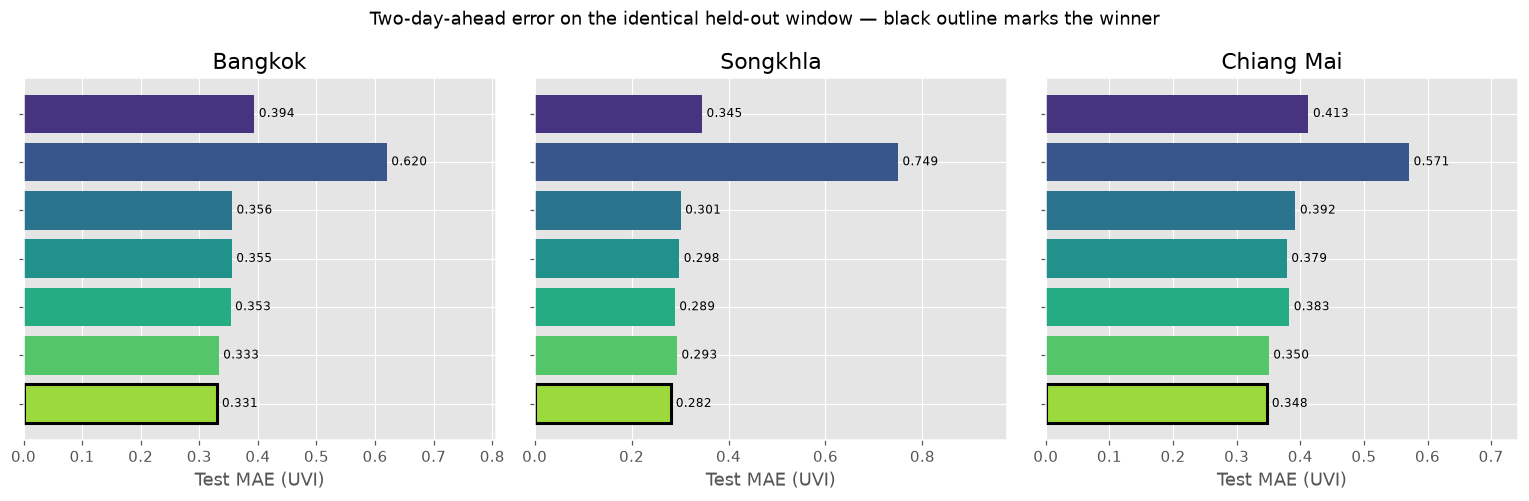

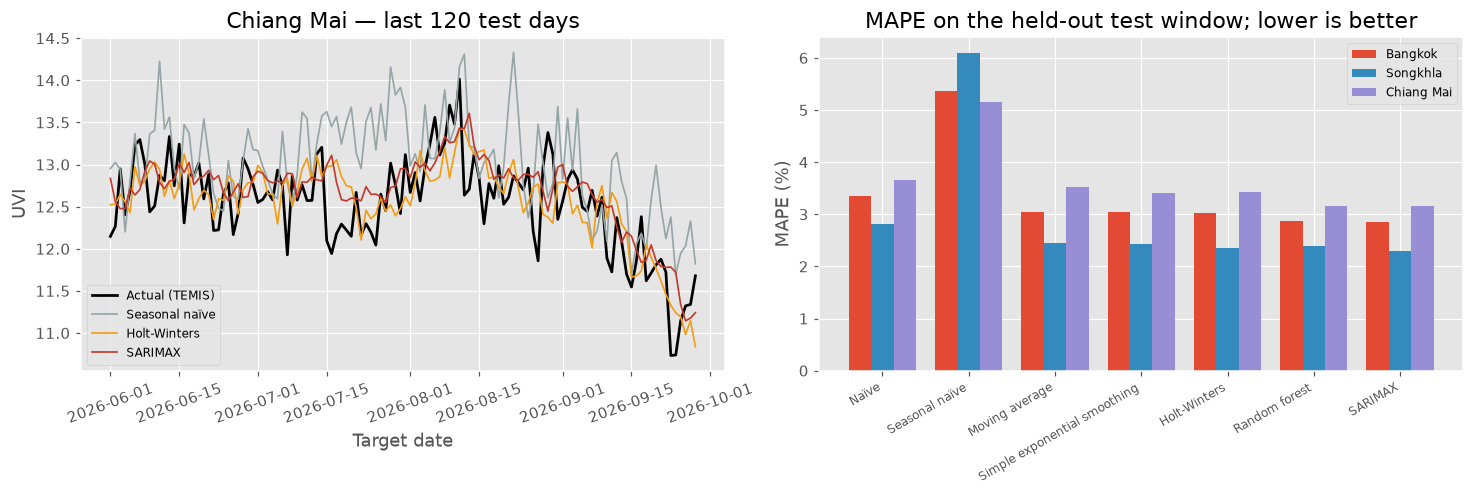

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), sharey=True)
positions = np.arange(len(MODEL_NAMES))
palette = plt.cm.viridis(np.linspace(0.15, 0.85, len(MODEL_NAMES)))
for ax, city in zip(axes, CITIES):
    heights = [comparison[city][name]["test"]["mae"] for name in MODEL_NAMES]
    bars = ax.barh(positions, heights, color=palette)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
    best = int(np.argmin(heights))
    bars[best].set_edgecolor("black")
    bars[best].set_linewidth(2)
    ax.set_yticks(positions, MODEL_NAMES if ax is axes[0] else [""] * len(MODEL_NAMES))
    ax.invert_yaxis()
    ax.set_xlabel("Test MAE (UVI)")
    ax.set_title(CITY_LABELS[city])
    ax.set_xlim(0, max(heights) * 1.3)
fig.suptitle("Two-day-ahead error on the identical held-out window — black outline marks the winner")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
city = "chiang_mai"
days, values = uv_series[city]
test_stop = test_windows[city].stop
recent = slice(test_stop - 120, test_stop)
axes[0].plot(days[recent], values[recent], color="black", lw=1.8, label="Actual (TEMIS)")
for name, colour in (("Seasonal naïve", "#95a5a6"), ("Holt-Winters", "#f39c12"), ("SARIMAX", "#c0392b")):
    axes[0].plot(days[recent], comparison[city][name]["predicted"][recent], lw=1.1, color=colour, label=name)
axes[0].set(title=f"{CITY_LABELS[city]} — last 120 test days", ylabel="UVI", xlabel="Target date")
axes[0].legend(loc="lower left", fontsize=8)
axes[0].tick_params(axis="x", rotation=20)

width = 0.26
index = np.arange(len(MODEL_NAMES))
for offset, other_city in enumerate(CITIES):
    axes[1].bar(index + (offset - 1) * width,
                [comparison[other_city][name]["test"]["mape"] for name in MODEL_NAMES],
                width, label=CITY_LABELS[other_city])
axes[1].set_xticks(index, MODEL_NAMES, rotation=30, ha="right", fontsize=8)
axes[1].set(title="MAPE on the held-out test window; lower is better", ylabel="MAPE (%)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. ประเมินผลที่บันทึกไว้

ส่วนนี้เป็นการตรวจสอบ artifact ของระบบจริง ใช้ `metrics.json` กับ `backtest_predictions.csv` ที่ได้จากการฝึกครั้งก่อน ตรวจค่า SHA-256 ของ CSV ปัจจุบันและแจ้งเมื่อไม่ตรงกับ snapshot ตอนฝึก จากนั้นตรวจจำนวนแถวและ MAE ของ backtest กับ metrics เดิมก่อนคำนวณ `evaluation.json` ใหม่ **ผลประเมินอ้างอิง backtest ที่บันทึกไว้ ไม่ใช่การทำนายจาก CSV ปัจจุบัน** ไม่โหลดโมเดล `.pkl` และไม่เรียก `SARIMAX.fit()` กราฟทั้งหมดด้านล่างใช้ผลทำนายล่วงหน้า 2 วันที่บันทึกไว้

นอกจาก MAE/RMSE ส่วนนี้ยังคำนวณสถิติที่ตารางเปรียบเทียบในส่วนที่ 5 ไม่ได้ให้ ได้แก่ ช่วงความเชื่อมั่นของส่วนต่างด้วย block bootstrap, ผลแยกรายเดือนและรายปี, และจำนวนวันที่พลาดเกณฑ์เตือน

In [18]:
"""Audit held-out two-day UV forecasts before using them in the app."""

import csv
import hashlib
import json
from collections import defaultdict
from datetime import date
from pathlib import Path

import numpy as np


ARTIFACTS = ROOT / "storage/artifacts/uv"
DATA = ROOT / "storage/data/uv/temis_clear_sky_uv.csv"
THRESHOLDS = (8, 11)


def block_bootstrap_ci(improvements, *, block=14, repeats=2000, seed=42):
    """Percentile interval for paired daily MAE gains, retaining short-run dependence."""
    gains = np.asarray(improvements, dtype=float)
    if len(gains) < block:
        raise ValueError("Not enough test days for a block bootstrap")
    rng = np.random.default_rng(seed)
    starts = rng.integers(0, len(gains) - block + 1,
                          size=(repeats, (len(gains) + block - 1) // block))
    samples = (starts[:, :, None] + np.arange(block)).reshape(repeats, -1)[:, :len(gains)]
    return [round(float(value), 4) for value in np.quantile(gains[samples].mean(axis=1),
                                                            (0.025, 0.975))]


def threshold_counts(actual, predicted, threshold):
    # Public UV categories use whole-number UVI, so compare displayed values.
    actual_high = np.floor(actual + 0.5) >= threshold
    predicted_high = np.floor(predicted + 0.5) >= threshold
    return {
        "actual_at_or_above": int(actual_high.sum()),
        "undercalled": int((actual_high & ~predicted_high).sum()),
        "false_alarms": int((~actual_high & predicted_high).sum()),
    }


def evaluate_saved_backtest():
    metrics = json.loads((ARTIFACTS / "metrics.json").read_text(encoding="utf-8"))
    if hashlib.sha256(DATA.read_bytes()).hexdigest() != metrics["source_sha256"]:
        print("NOTICE: Current CSV differs from the training snapshot; the evaluation below uses saved backtest rows only.")

    grouped = defaultdict(list)
    with (ARTIFACTS / "backtest_predictions.csv").open(newline="", encoding="utf-8") as file:
        for row in csv.DictReader(file):
            if row["split"] == "test" and row["sarimax_h2"]:
                grouped[row["city"]].append(row)
    if set(grouped) != set(metrics["cities"]):
        raise ValueError("Prediction cities do not match training metrics")

    report = {"horizon_days": 2, "split": "test", "bootstrap_block_days": 14,
              "bootstrap_repeats": 2000, "cities": {}}
    for city, rows in grouped.items():
        days = [date.fromisoformat(row["date"]) for row in rows]
        if len(set(days)) != len(days) or days != sorted(days):
            raise ValueError(f"Duplicate or unsorted test dates: {city}")
        actual = np.array([float(row["actual"]) for row in rows])
        model = np.array([float(row["sarimax_h2"]) for row in rows])
        baseline = np.array([float(row["persistence_h2"]) for row in rows])
        if not np.isfinite(np.column_stack((actual, model, baseline))).all():
            raise ValueError(f"Nonfinite test value: {city}")

        absolute_error = np.abs(model - actual)
        baseline_error = np.abs(baseline - actual)
        mae = float(absolute_error.mean())
        saved = metrics["cities"][city]["test"]["sarimax_h2"]
        if len(rows) != saved["n"] or round(mae, 4) != saved["mae"]:
            raise ValueError(f"Backtest rows disagree with metrics: {city}")
        by_year = {}
        by_month = {}
        for label, groups in ((by_year, [day.year for day in days]),
                              (by_month, [day.month for day in days])):
            for key in sorted(set(groups)):
                mask = np.array([group == key for group in groups])
                label[str(key)] = {
                    "n": int(mask.sum()),
                    "model_mae": round(float(absolute_error[mask].mean()), 4),
                    "persistence_mae": round(float(baseline_error[mask].mean()), 4),
                }

        city_report = {
            "n": len(rows),
            "dates": [days[0].isoformat(), days[-1].isoformat()],
            "mae": round(mae, 4),
            "rmse": round(float(np.sqrt(np.mean((model - actual) ** 2))), 4),
            "bias_predicted_minus_actual": round(float(np.mean(model - actual)), 4),
            "p90_absolute_error": round(float(np.quantile(absolute_error, 0.9)), 4),
            "max_absolute_error": round(float(absolute_error.max()), 4),
            "persistence_mae": round(float(baseline_error.mean()), 4),
            "mae_gain_over_persistence": round(float((baseline_error - absolute_error).mean()), 4),
            "mae_gain_95pct_block_bootstrap_ci": block_bootstrap_ci(
                baseline_error - absolute_error
            ),
            "months_beating_persistence": sum(
                item["model_mae"] < item["persistence_mae"] for item in by_month.values()
            ),
            "by_year": by_year,
            "by_month": by_month,
            "thresholds": {
                str(threshold): threshold_counts(actual, model, threshold)
                for threshold in THRESHOLDS
            },
        }
        report["cities"][city] = city_report
        print(f"{city}: MAE {city_report['mae']}, gain 95% CI "
              f"{city_report['mae_gain_95pct_block_bootstrap_ci']}, "
              f"months beating persistence {city_report['months_beating_persistence']}/12")

    output = ARTIFACTS / "evaluation.json"
    output.write_text(json.dumps(report, indent=2) + "\n", encoding="utf-8")
    print(f"Saved {output}")

metrics_path = ARTIFACTS / "metrics.json"
predictions_path = ARTIFACTS / "backtest_predictions.csv"
required = [DATA, metrics_path, predictions_path]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Saved evaluation inputs are missing; nothing will be downloaded or retrained: "
        + ", ".join(missing)
    )
evaluate_saved_backtest()
print("Evaluation reused the saved CSV and backtest predictions; SARIMAX was not fitted.")


NOTICE: Current CSV differs from the training snapshot; the evaluation below uses saved backtest rows only.
bangkok: MAE 0.3309, gain 95% CI [0.0429, 0.082], months beating persistence 11/12
songkhla: MAE 0.2819, gain 95% CI [0.0492, 0.0776], months beating persistence 12/12
chiang_mai: MAE 0.3482, gain 95% CI [0.044, 0.0852], months beating persistence 11/12
Saved D:\CoE Y.4 T.1\241-353\code\Aphrodize\storage\artifacts\uv\evaluation.json
Evaluation reused the saved CSV and backtest predictions; SARIMAX was not fitted.


### วิธีอ่านผล

MAE/RMSE ยิ่งต่ำยิ่งดี เปรียบเทียบ SARIMAX กับการใช้ค่า UV ล่าสุดซ้ำ (persistence) และค่าในวันเดียวกันของปีก่อน (seasonal naive) ค่า bias คือค่าทำนายลบค่าจริง ตารางและกราฟใช้ชุด test ที่กันไว้

In [19]:
metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
audit = json.loads((ARTIFACTS / "evaluation.json").read_text(encoding="utf-8"))
rows_by_city = {city: [] for city in CITIES}
with predictions_path.open(newline="", encoding="utf-8") as file:
    for row in csv.DictReader(file):
        if row["split"] == "test" and row["sarimax_h2"]:
            rows_by_city[row["city"]].append(row)

lines = ["| City | Selected SARIMAX order | Validation MAE (2 days) | Test days |",
         "|---|---:|---:|---:|"]
for city in CITIES:
    result = metrics["cities"][city]
    lines.append(f"| {CITY_LABELS[city]} | {tuple(result['selected_order'])} | "
                 f"{result['validation']['sarimax_h2']['mae']:.4f} | {len(rows_by_city[city])} |")
display(Markdown("\n".join(lines)))

| City | Selected SARIMAX order | Validation MAE (2 days) | Test days |
|---|---:|---:|---:|
| Bangkok | (1, 0, 1) | 0.3229 | 635 |
| Songkhla | (1, 0, 1) | 0.3095 | 635 |
| Chiang Mai | (1, 0, 1) | 0.3600 | 635 |

In [20]:
scores = {}
lines = ["| City | SARIMAX MAE | Latest-value MAE | Previous-year MAE | RMSE | MAPE | Bias | P90 absolute error |",
         "|---|---:|---:|---:|---:|---:|---:|---:|"]
for city, rows in rows_by_city.items():
    actual = np.array([float(row["actual"]) for row in rows])
    predicted = np.array([float(row["sarimax_h2"]) for row in rows])
    latest = np.array([float(row["persistence_h2"]) for row in rows])
    previous_year = np.array([float(row["seasonal_naive"]) for row in rows])
    scores[city] = {
        "sarimax": float(np.mean(np.abs(predicted - actual))),
        "latest": float(np.mean(np.abs(latest - actual))),
        "previous_year": float(np.mean(np.abs(previous_year - actual))),
        "mape": float(np.mean(np.abs((predicted - actual) / actual)) * 100),
    }
    result = audit["cities"][city]
    lines.append(f"| {CITY_LABELS[city]} | {scores[city]['sarimax']:.4f} | "
                 f"{scores[city]['latest']:.4f} | {scores[city]['previous_year']:.4f} | "
                 f"{result['rmse']:.4f} | {scores[city]['mape']:.2f}% | "
                 f"{result['bias_predicted_minus_actual']:+.4f} | "
                 f"{result['p90_absolute_error']:.4f} |")
display(Markdown("\n".join(lines)))

| City | SARIMAX MAE | Latest-value MAE | Previous-year MAE | RMSE | MAPE | Bias | P90 absolute error |
|---|---:|---:|---:|---:|---:|---:|---:|
| Bangkok | 0.3309 | 0.3938 | 0.6199 | 0.4227 | 2.85% | +0.0856 | 0.6838 |
| Songkhla | 0.2819 | 0.3451 | 0.7494 | 0.3494 | 2.30% | +0.0566 | 0.5758 |
| Chiang Mai | 0.3482 | 0.4129 | 0.5710 | 0.4378 | 3.16% | +0.0978 | 0.7386 |

## 7. กราฟการประเมิน

กราฟต่อไปนี้แสดง MAE เทียบ baseline, ค่าจริงกับค่าทำนายช่วงท้าย, ความผิดพลาดรายเดือน และการกระจายของ residual

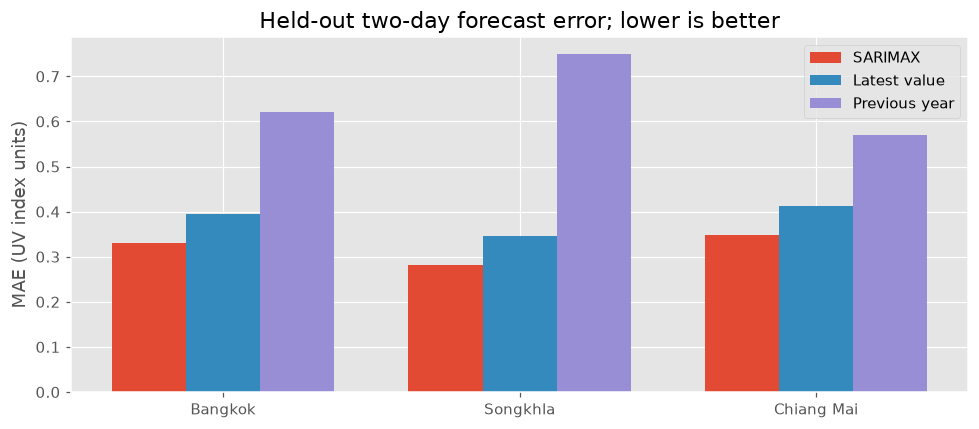

In [21]:
cities = list(CITIES)
x = np.arange(len(cities))
width = 0.25
fig, ax = plt.subplots(figsize=(9, 4))
for offset, (key, label) in enumerate((("sarimax", "SARIMAX"), ("latest", "Latest value"),
                                       ("previous_year", "Previous year"))):
    ax.bar(x + (offset - 1) * width, [scores[city][key] for city in cities], width, label=label)
ax.set_xticks(x, [CITY_LABELS[city] for city in cities])
ax.set_ylabel("MAE (UV index units)")
ax.set_title("Held-out two-day forecast error; lower is better")
ax.legend()
plt.tight_layout()
plt.show()

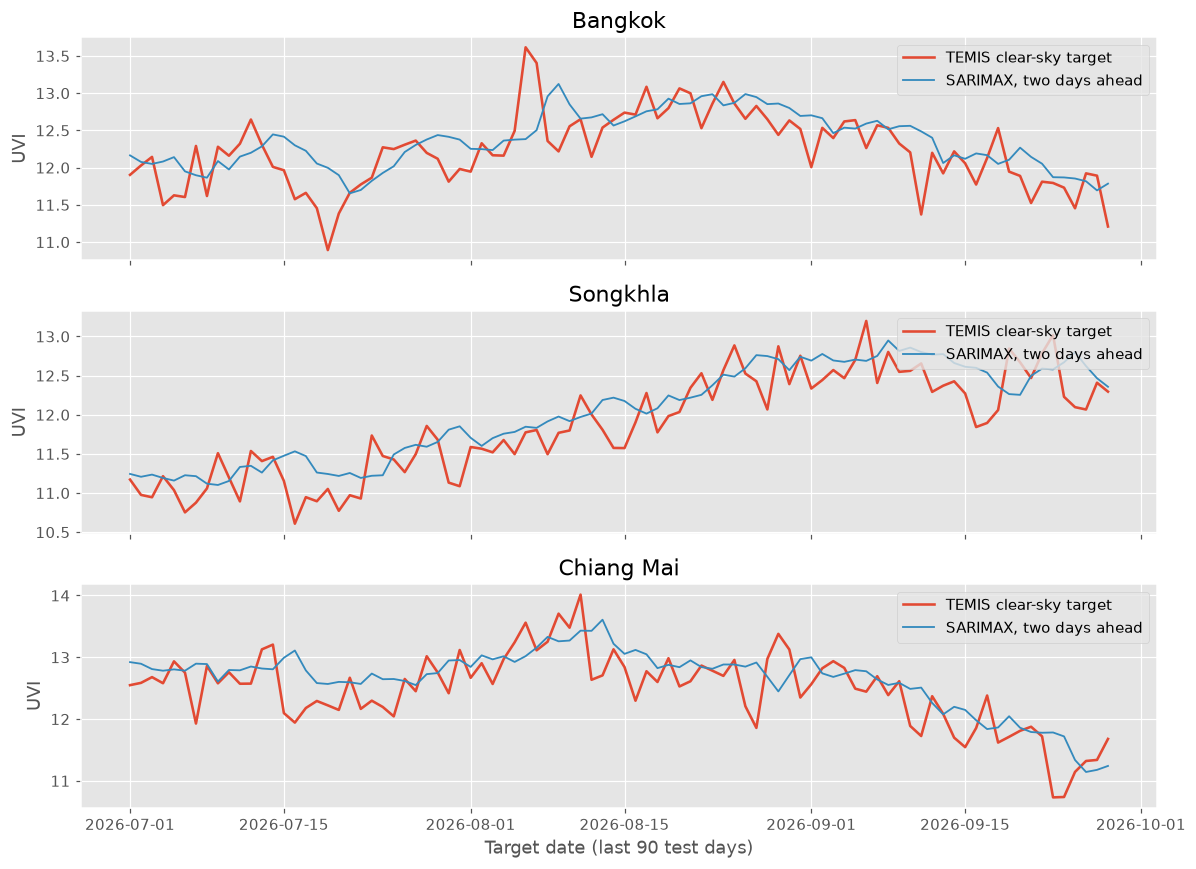

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for ax, city in zip(axes, cities):
    recent = rows_by_city[city][-90:]
    days = [date.fromisoformat(row["date"]) for row in recent]
    ax.plot(days, [float(row["actual"]) for row in recent], label="TEMIS clear-sky target", lw=1.7)
    ax.plot(days, [float(row["sarimax_h2"]) for row in recent], label="SARIMAX, two days ahead", lw=1.2)
    ax.set_title(CITY_LABELS[city])
    ax.set_ylabel("UVI")
    ax.legend(loc="upper right")
axes[-1].set_xlabel("Target date (last 90 test days)")
plt.tight_layout()
plt.show()

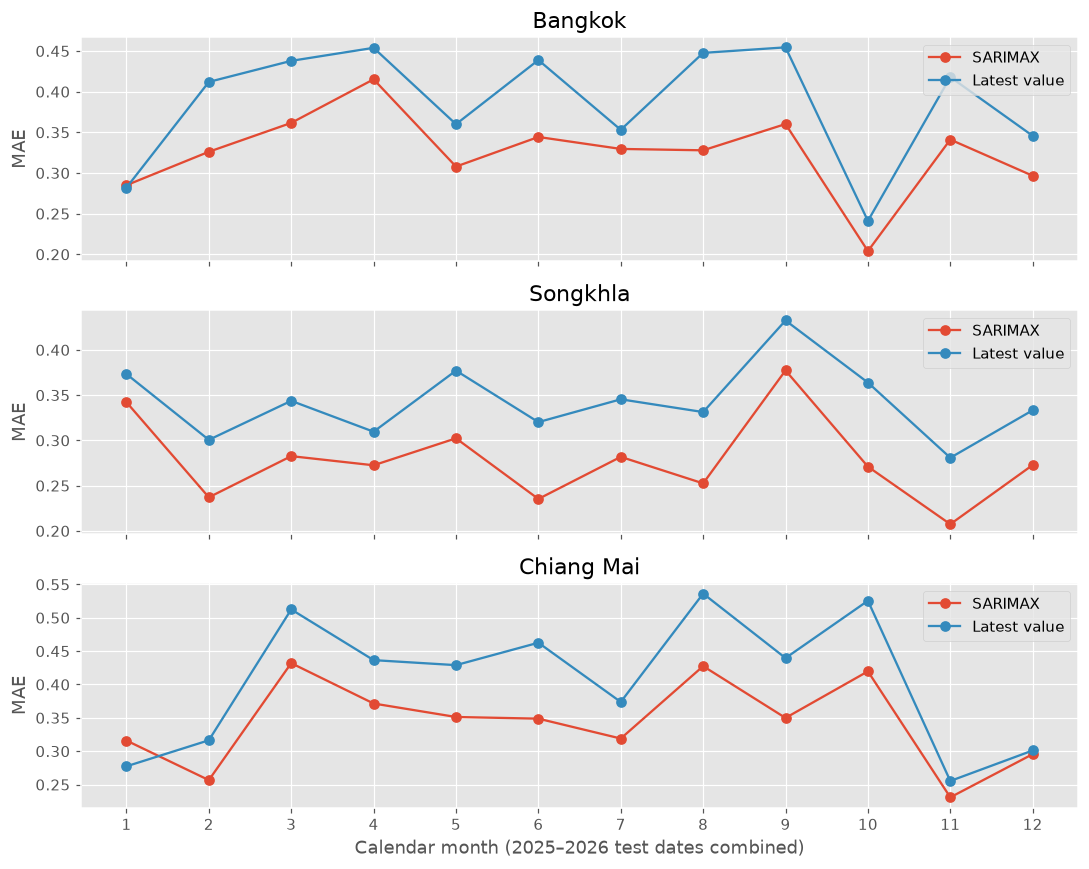

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for ax, city in zip(axes, cities):
    monthly = audit["cities"][city]["by_month"]
    months = np.arange(1, 13)
    ax.plot(months, [monthly[str(month)]["model_mae"] for month in months], marker="o", label="SARIMAX")
    ax.plot(months, [monthly[str(month)]["persistence_mae"] for month in months],
            marker="o", label="Latest value")
    ax.set_title(CITY_LABELS[city])
    ax.set_ylabel("MAE")
    ax.legend(loc="upper right")
axes[-1].set_xticks(months)
axes[-1].set_xlabel("Calendar month (2025–2026 test dates combined)")
plt.tight_layout()
plt.show()

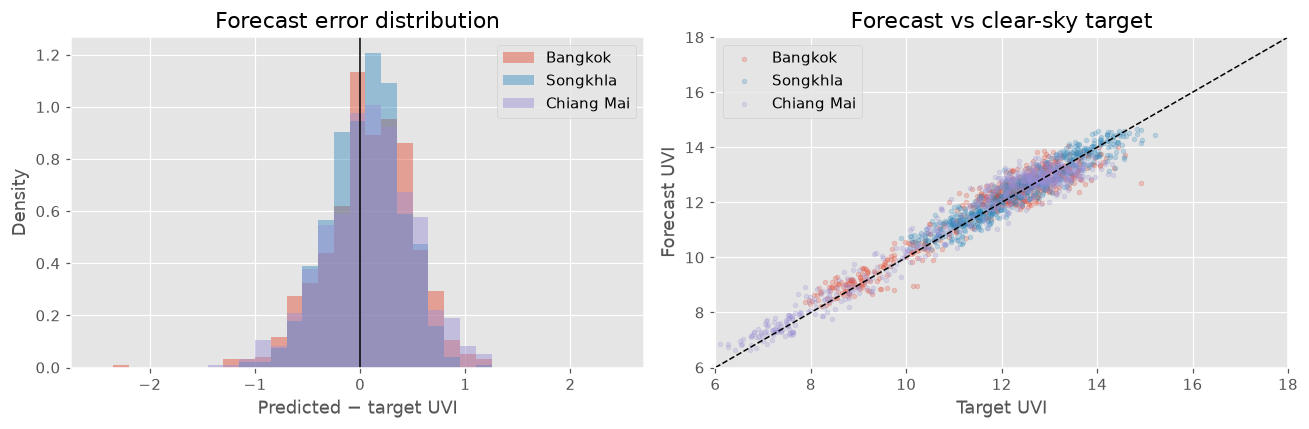

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for city, rows in rows_by_city.items():
    actual = np.array([float(row["actual"]) for row in rows])
    predicted = np.array([float(row["sarimax_h2"]) for row in rows])
    axes[0].hist(predicted - actual, bins=np.arange(-2.5, 2.6, 0.15), alpha=0.45,
                 density=True, label=CITY_LABELS[city])
    axes[1].scatter(actual, predicted, s=9, alpha=0.25, label=CITY_LABELS[city])
axes[0].axvline(0, color="black", lw=1)
axes[0].set(title="Forecast error distribution", xlabel="Predicted − target UVI", ylabel="Density")
axes[1].plot([6, 18], [6, 18], color="black", lw=1, ls="--")
axes[1].set(title="Forecast vs clear-sky target", xlabel="Target UVI", ylabel="Forecast UVI",
            xlim=(6, 18), ylim=(6, 18))
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

## 8. ความเสี่ยงใกล้จุดแบ่งระดับ UV

MAE บอกความคลาดเคลื่อนเฉลี่ย แต่ไม่บอกว่าความคลาดเคลื่อนนั้น *ตกลงตรงไหน* สำหรับแอปเตือนภัย ความผิดพลาด 0.3 UVI ในวันที่ค่าจริงเท่ากับ 13 แทบไม่มีผล แต่ความผิดพลาดขนาดเดียวกันในวันที่ค่าจริงเท่ากับ 11.0 อาจเปลี่ยนคำเตือนจาก Extreme เป็น Very High

ส่วนนี้จึงนับวันที่ค่าจริงหลังปัดเป็น UVI จำนวนเต็มถึงระดับ 8 หรือ 11 แต่ค่าทำนายยังต่ำกว่า (under-call คือเตือนน้อยกว่าที่ควร ซึ่งอันตรายกว่า false alarm) ตารางและกราฟนี้ช่วยตรวจการพลาดคำเตือนระดับสูง ไม่ได้พิสูจน์ความแม่นยำของ UV ในวันที่มีเมฆ

In [25]:
lines = ["| City | UV ≥8 under-called / target days | UV ≥11 under-called / target days | "
         "Months beating latest-value baseline | 95% block-bootstrap MAE gain |",
         "|---|---:|---:|---:|---:|"]
for city in cities:
    result = audit["cities"][city]
    low8 = result["thresholds"]["8"]
    extreme = result["thresholds"]["11"]
    ci = result["mae_gain_95pct_block_bootstrap_ci"]
    lines.append(f"| {CITY_LABELS[city]} | {low8['undercalled']}/{low8['actual_at_or_above']} | "
                 f"{extreme['undercalled']}/{extreme['actual_at_or_above']} | "
                 f"{result['months_beating_persistence']}/12 | "
                 f"{result['mae_gain_over_persistence']:.4f} [{ci[0]:.4f}, {ci[1]:.4f}] |")
display(Markdown("\n".join(lines)))

| City | UV ≥8 under-called / target days | UV ≥11 under-called / target days | Months beating latest-value baseline | 95% block-bootstrap MAE gain |
|---|---:|---:|---:|---:|
| Bangkok | 0/635 | 3/492 | 11/12 | 0.0629 [0.0429, 0.0820] |
| Songkhla | 0/635 | 5/609 | 12/12 | 0.0633 [0.0492, 0.0776] |
| Chiang Mai | 9/578 | 2/447 | 11/12 | 0.0647 [0.0440, 0.0852] |

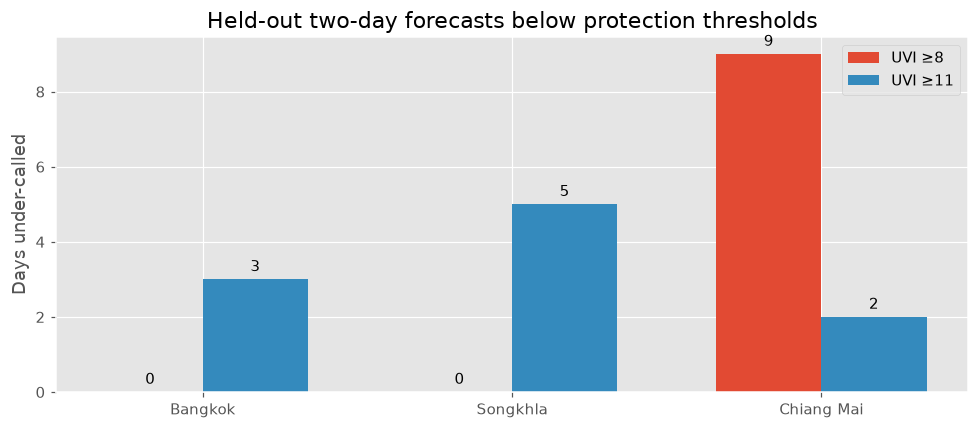

In [26]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(cities))
width = 0.34
for offset, threshold in enumerate((8, 11)):
    undercalled = [audit["cities"][city]["thresholds"][str(threshold)]["undercalled"] for city in cities]
    bars = ax.bar(x + (offset - 0.5) * width, undercalled, width, label=f"UVI ≥{threshold}")
    ax.bar_label(bars, padding=3)
ax.set_xticks(x, [CITY_LABELS[city] for city in cities])
ax.set_ylabel("Days under-called")
ax.set_title("Held-out two-day forecasts below protection thresholds")
ax.legend()
plt.tight_layout()
plt.show()


## 9. วิเคราะห์และสรุปผล

### 9.1 โมเดลที่ดีที่สุดคืออะไร และทำไมจึงเลือก

**คำตอบ: SARIMAX(1,0,1) พร้อม Fourier 2 harmonics เป็น exogenous regressors** — มี MAE เฉลี่ยต่ำที่สุดบนชุด validation และชนะทั้ง 3 เมืองบนชุด test ที่ไม่เคยถูกแตะในขั้นตอนเลือกโมเดล

**เหตุผลที่ 1 — ชนะบนตัวเลขที่ใช้ตัดสินใจ ไม่ใช่ตัวเลขที่ใช้รายงานผล** บน validation ปี 2024 SARIMAX มี MAE เฉลี่ยต่ำที่สุด (0.3308) และต่ำที่สุดใน 2 จาก 3 เมือง (กรุงเทพ 0.3229, เชียงใหม่ 0.3600) ส่วนสงขลาแพ้ Holt-Winters อย่างฉิวเฉียดที่ 0.3095 เทียบ 0.3082 (ต่างกัน 0.4%) เมื่อเปิดชุด test SARIMAX ชนะ **ทั้งสามเมือง** รวมถึงสงขลาที่เคยแพ้ (0.2819 เทียบ Holt-Winters ที่ 0.2890) ผลบน test จึงเป็น*การยืนยัน* ไม่ใช่การเลือก ถ้าเลือกจาก test แล้วรายงาน test ตัวเลขที่ได้จะเป็นคะแนนของผู้ชนะที่ถูกคัดมาแล้วและสูงเกินจริง

**เหตุผลที่ 2 — ส่วนต่างมีนัยสำคัญทางสถิติ ไม่ใช่ความบังเอิญ** block bootstrap (บล็อก 14 วัน, 2,000 รอบ ซึ่งรักษาความสัมพันธ์ระหว่างวันที่ติดกันไว้) ให้ช่วงความเชื่อมั่น 95% ของส่วนต่าง MAE เทียบ naïve ที่ **ไม่คร่อมศูนย์ทั้งสามเมือง** และ SARIMAX ชนะ naïve ใน 11–12 เดือนจาก 12 เดือน แปลว่าความได้เปรียบนี้กระจายทั่วทั้งปี ไม่ได้มาจากฤดูกาลใดฤดูกาลหนึ่ง

**เหตุผลที่ 3 — โครงสร้างของโมเดลตรงกับโครงสร้างของข้อมูลที่ EDA พบ** EDA ชี้ว่าข้อมูลประกอบด้วยฤดูกาลที่กำหนดได้จากปฏิทิน (R² 0.84–0.94) บวกความจำระยะสั้นไม่กี่วัน (ACF residual ≈ 0.6–0.7 ที่ lag 1) SARIMAX จัดการสองส่วนนี้ด้วยกลไกคนละตัวพอดี — Fourier exogenous รับส่วนฤดูกาล และพจน์ AR(1)+MA(1) รับส่วนความจำ นี่คือเหตุผลที่มันชนะ Holt-Winters ซึ่งต้องใช้กลไกเดียว (ฤดูกาลที่ค่อย ๆ ปรับตัว) ทำงานทั้งสองหน้าที่

**เหตุผลที่ 4 — ชนะ Random Forest ด้วยต้นทุนที่ต่ำกว่ามาก** Random forest ตามมาเป็นอันดับสองในกรุงเทพและเชียงใหม่โดยห่างกันเพียง 0.6% ของ MAE (และเป็นอันดับสามในสงขลา) แต่ต้องการ 300 ต้นไม้ ไฟล์โมเดลใหญ่กว่าหลายเท่า ไม่ให้ช่วงความเชื่อมั่นของการพยากรณ์ และ **ไม่สามารถพยากรณ์นอกช่วงค่าที่เคยเห็น** (tree-based model ทำนายได้เฉพาะค่าเฉลี่ยของใบไม้) ซึ่งเป็นข้อจำกัดอันตรายสำหรับระบบเตือนภัยที่ต้องรับมือกับวันที่ UV ทำสถิติใหม่ เมื่อความแม่นยำเท่ากัน โมเดลที่เรียบง่ายและตีความได้จึงเป็นตัวเลือกที่ถูกต้อง

**เหตุผลที่ 5 — baseline ที่ถูกคัดออกบอกอะไรสำคัญ** Seasonal naïve แพ้ขาด (MAE 0.57–0.75 หรือแย่กว่าผู้ชนะ 1.6–2.7 เท่า และแย่กว่าแม้แต่ Naïve ที่ทำเพียงใช้ค่าของเมื่อวานซืนซ้ำ) ทั้งที่ข้อมูลมีฤดูกาลเด่นมาก ข้อเท็จจริงนี้ยืนยันว่า**ค่าล่าสุดมีข้อมูลที่ปฏิทินให้ไม่ได้** และโมเดลที่ดีต้องใช้ทั้งสองอย่าง ไม่ใช่อย่างใดอย่างหนึ่ง

In [27]:
verdict_lines = ["| เกณฑ์ตัดสิน | " + " | ".join(CITY_LABELS[city] for city in CITIES) + " |",
                 "|---|---|---|---|"]


def best_model(city, split):
    return min(MODEL_NAMES, key=lambda name: comparison[city][name][split]["mae"])


def row(label, render):
    verdict_lines.append(f"| {label} | " + " | ".join(render(city) for city in CITIES) + " |")


row("โมเดลที่ MAE ต่ำสุดบน validation", lambda city: best_model(city, "validation"))
row("โมเดลที่ MAE ต่ำสุดบน test", lambda city: best_model(city, "test"))
row("SARIMAX test MAE", lambda city: f"{comparison[city]['SARIMAX']['test']['mae']:.4f}")
row("อันดับ 2 และ MAE", lambda city: (lambda ranked: f"{ranked[1]} ({comparison[city][ranked[1]]['test']['mae']:.4f})")(
    sorted(MODEL_NAMES, key=lambda name: comparison[city][name]["test"]["mae"])))
row("ดีกว่า Naïve", lambda city: f"{(1 - comparison[city]['SARIMAX']['test']['mae'] / comparison[city]['Naïve']['test']['mae']) * 100:.1f}%")
row("ดีกว่า Seasonal naïve", lambda city: f"{(1 - comparison[city]['SARIMAX']['test']['mae'] / comparison[city]['Seasonal naïve']['test']['mae']) * 100:.1f}%")
row("ส่วนต่าง MAE จาก Naïve (95% block bootstrap)",
    lambda city: f"{audit['cities'][city]['mae_gain_over_persistence']:.4f} "
                 f"[{audit['cities'][city]['mae_gain_95pct_block_bootstrap_ci'][0]:.4f}, "
                 f"{audit['cities'][city]['mae_gain_95pct_block_bootstrap_ci'][1]:.4f}]")
row("เดือนที่ชนะ Naïve", lambda city: f"{audit['cities'][city]['months_beating_persistence']}/12")
row("พลาดเตือน UVI ≥ 11", lambda city: f"{audit['cities'][city]['thresholds']['11']['undercalled']}/"
                                        f"{audit['cities'][city]['thresholds']['11']['actual_at_or_above']} วัน")

display(Markdown("### ตารางสรุปการตัดสินใจเลือกโมเดล\n" + "\n".join(verdict_lines)))

### ตารางสรุปการตัดสินใจเลือกโมเดล
| เกณฑ์ตัดสิน | Bangkok | Songkhla | Chiang Mai |
|---|---|---|---|
| โมเดลที่ MAE ต่ำสุดบน validation | SARIMAX | Holt-Winters | SARIMAX |
| โมเดลที่ MAE ต่ำสุดบน test | SARIMAX | SARIMAX | SARIMAX |
| SARIMAX test MAE | 0.3309 | 0.2819 | 0.3482 |
| อันดับ 2 และ MAE | Random forest (0.3330) | Holt-Winters (0.2890) | Random forest (0.3504) |
| ดีกว่า Naïve | 16.0% | 18.3% | 15.7% |
| ดีกว่า Seasonal naïve | 46.6% | 62.4% | 39.0% |
| ส่วนต่าง MAE จาก Naïve (95% block bootstrap) | 0.0629 [0.0429, 0.0820] | 0.0633 [0.0492, 0.0776] | 0.0647 [0.0440, 0.0852] |
| เดือนที่ชนะ Naïve | 11/12 | 12/12 | 11/12 |
| พลาดเตือน UVI ≥ 11 | 3/492 วัน | 5/609 วัน | 2/447 วัน |

### 9.2 ผลการพยากรณ์ช่วยตัดสินใจเชิงธุรกิจ/นโยบายได้อย่างไร

**ก. เปลี่ยนการเตือนจาก "ตอบสนอง" เป็น "ล่วงหน้า"** ค่า UV ที่วัดได้บอกสิ่งที่เกิดขึ้นแล้ว การพยากรณ์ล่วงหน้า 2 วันเปิดหน้าต่างให้ผู้ใช้วางแผน เช่น เลื่อนกิจกรรมกลางแจ้ง เตรียมครีมกันแดด หรือจัดตารางงานใหม่ ที่ MAE ≈ 0.3 UVI โมเดลแยกระดับ WHO ที่ห่างกัน 3 หน่วยได้อย่างสบาย ความคลาดเคลื่อนนี้เล็กกว่าความกว้างของช่วงระดับหนึ่งขั้น (2–3 หน่วย) ประมาณ 7–10 เท่า

**ข. จัดสรรทรัพยากรด้านสาธารณสุขตามพื้นที่และฤดูกาล** EDA ให้ภาพที่ใช้วางแผนงบประมาณได้ทันที — สงขลาอยู่ในระดับ Extreme 87.1% ของวันทั้งปี ขณะที่เชียงใหม่มีช่วงผ่อนคลายชัดเจนในเดือน พ.ย.–ม.ค. แปลว่าแคมเปญให้ความรู้เรื่องมะเร็งผิวหนังในภาคใต้ควรเป็นงานตลอดปี ส่วนภาคเหนือควรเร่งเป็นพิเศษช่วง มี.ค.–พ.ค.

**ค. ตั้งค่าใช้จ่ายของระบบตามความเสี่ยงที่ยอมรับได้** โมเดลมี bias เป็นบวกเล็กน้อย (+0.06 ถึง +0.10 UVI) แปลว่ามีแนวโน้มเตือนเกินมากกว่าเตือนขาด ซึ่ง**เป็นทิศทางที่ถูกต้องสำหรับระบบความปลอดภัย** ที่เกณฑ์ UVI ≥ 11 โมเดลพลาดการเตือนเพียง 2–5 วันจาก 447–609 วันเป้าหมาย (< 1%) และที่เกณฑ์ ≥ 8 พลาด 0–9 วัน ต้นทุนของ false alarm คือผู้ใช้ทาครีมกันแดดโดยไม่จำเป็น ส่วนต้นทุนของการพลาดเตือนคือผิวไหม้ — อัตราแลกเปลี่ยนนี้ไม่สมมาตรอย่างชัดเจน และโมเดลวางตัวอยู่ด้านที่ปลอดภัย

**ง. รองรับการตรวจสอบย้อนหลัง** ทุกตัวเลขในรายงานนี้สืบกลับไปถึง SHA-256 ของไฟล์ข้อมูลต้นทางได้ เมื่อหน่วยงานถามว่า "ทำไมวันนั้นระบบถึงเตือนระดับนั้น" คำตอบมีหลักฐานครบ ไม่ใช่ผลลัพธ์จาก API ภายนอกที่ตรวจสอบไม่ได้

**จ. ข้อควรระวังเชิงนโยบาย** ตัวเลขทั้งหมดนี้เป็น UV ภายใต้ท้องฟ้าโปร่ง จึงเป็น **ขอบบนของความเสี่ยง** ใช้ประกอบการตัดสินใจเชิงป้องกันได้ดี แต่**ห้ามใช้อ้างอิงปริมาณรังสีที่ผู้ใช้ได้รับจริง** ในเอกสารทางการแพทย์หรือรายงานการสัมผัสรังสีสะสม

### 9.3 ข้อจำกัดของการทำ Forecasting ใน dataset นี้

1. **เป้าหมายไม่ใช่ UV ที่ผู้ใช้ได้รับจริง** นี่คือข้อจำกัดที่ใหญ่ที่สุด TEMIS ให้ค่าภายใต้สมมติฐานท้องฟ้าโปร่ง ณ เที่ยงสุริยะ วันที่ฝนตกในกรุงเทพฯ ค่าจริงที่ผิวโลกอาจต่ำกว่าตัวเลขนี้ 50–90% การประเมินทั้งหมดในสมุดเล่มนี้จึงพิสูจน์ได้เพียงว่าโมเดล**ทำนายค่าอ้างอิงของ TEMIS** ได้แม่น ไม่ได้พิสูจน์ว่าแอปบอกความเสี่ยงที่ผู้ใช้เผชิญได้แม่น การจะปิดช่องว่างนี้ต้องมีข้อมูลเมฆและข้อมูลวัดภาคพื้นดินซึ่ง dataset นี้ไม่มี
2. **เพดานความแม่นยำถูกกำหนดโดยธรรมชาติของข้อมูล** ฤดูกาลอธิบายความแปรปรวนไปแล้ว 84–94% ส่วนที่เหลือคือความผันผวนของโอโซนที่มีลักษณะใกล้เคียงสัญญาณรบกวน ผลลัพธ์ที่เห็นคือโมเดลทุกตัวที่ใช้ข้อมูลล่าสุด (ตั้งแต่ moving average ไปจนถึง SARIMAX) ได้ MAE อยู่ในช่วงแคบ ๆ ที่ 0.28–0.41 — **ระยะห่างระหว่าง Naïve ที่ง่ายที่สุดกับ SARIMAX ที่ดีที่สุดมีเพียง 16–18%** การลงทุนในโมเดลที่ซับซ้อนกว่านี้ (LSTM, Transformer) จึงมีแนวโน้มให้ผลตอบแทนที่ลดน้อยถอยลงอย่างรุนแรง
3. **มีตัวแปรต้นเพียงตัวเดียวคือวันที่** โมเดลไม่มีข้อมูลโอโซน (ซึ่งเป็นสาเหตุทางกายภาพโดยตรงของ residual), ความสูงของเมฆ, ฝุ่น PM2.5 หรือหมอกควันจากการเผา ซึ่งลด UV ที่ผิวโลกได้มากในภาคเหนือช่วง มี.ค.–เม.ย. การเพิ่มตัวแปรเหล่านี้น่าจะให้ผลตอบแทนสูงกว่าการเปลี่ยนสถาปัตยกรรมโมเดลมาก
4. **ความแม่นยำเสื่อมลงเมื่อ horizon ยาวขึ้น** ข้อมูลอ้างอิงเพียงอย่างเดียวที่โมเดลใช้คือค่าล่าสุดและปฏิทิน เมื่อพยากรณ์ไกลเกิน 2–3 วัน พจน์ AR จะสลายตัวจนค่าทำนายลู่เข้าหาเส้นฤดูกาล และผลจะเท่ากับการเปิดตารางค่าเฉลี่ยรายวัน ระบบจึงจำกัด horizon ไว้ที่ 2 วันโดยเจตนา ไม่ใช่เพราะข้อจำกัดทางเทคนิค
5. **ครอบคลุมเพียง 3 จุด** โมเดลฝึกแยกสำหรับกรุงเทพ สงขลา เชียงใหม่ การนำไปใช้กับจังหวัดอื่นต้องอาศัยการประมาณค่าเชิงพื้นที่ซึ่งยังไม่ได้ตรวจสอบความถูกต้อง และค่า UV แปรผันตามละติจูดอย่างมีนัยสำคัญตามที่เห็นในส่วนที่ 2
6. **โมเดลไม่มีทางรู้เหตุการณ์ที่ไม่เคยเห็น** ภูเขาไฟระเบิดขนาดใหญ่ เหตุการณ์โอโซนบางผิดปกติ หรือการเปลี่ยนเครื่องมือวัดบนดาวเทียม จะทำให้ค่าจริงเคลื่อนออกจากที่โมเดลเรียนรู้ไว้ ระบบจึงต้องมีการเฝ้าระวังค่าคลาดเคลื่อนอย่างต่อเนื่อง ไม่ใช่ฝึกครั้งเดียวแล้วใช้ตลอดไป
7. **ข้อมูลล่าช้าจากแหล่งต้นทาง** TEMIS เผยแพร่ข้อมูลเป็นรอบ ถ้าไฟล์ล่าสุดขาดไปหลายวัน ค่า lag ที่โมเดลใช้จะเก่ากว่าที่ออกแบบไว้ และคุณภาพการพยากรณ์จะลดลงโดยที่ metrics ย้อนหลังมองไม่เห็นปัญหานี้

## 10. ขอบเขตของผลลัพธ์

ผลประเมินนี้เป็นของ **clear-sky UV** ที่ TEMIS ประมาณ ณ เที่ยงสุริยะ ไม่ใช่การตรวจความถูกต้องของ UV จริงภายใต้เมฆหรือการสัมผัส UV ของผู้ใช้ Open-Meteo ใช้แสดงสภาพอากาศประกอบในแอป ไม่ใช่ feature ของ SARIMAX รายละเอียดเกณฑ์เผยแพร่และข้อจำกัดอยู่ใน `docs/uv-data-feasibility.md`

ตัวเลขทุกตัวในส่วนที่ 6–8 มาจาก backtest ที่บันทึกไว้พร้อม SHA-256 ของข้อมูลต้นทาง ส่วนตัวเลขเปรียบเทียบโมเดลในส่วนที่ 5 คำนวณสดจาก CSV ปัจจุบันบนหน้าต่าง test เดียวกัน การรันซ้ำจึงให้ผลเดิมตราบใดที่ไฟล์ทั้งสองไม่เปลี่ยน